# 전체 게임 출시 전 LLM 리뷰 분석 보고서

이 노트북은 `03_run_llm_allgames_analysi.ipynb`에서 만든 LLM 분석 결과를 사용해  
**Steam 인디게임의 출시 전 점검 근거**를 정리하는 보고서다.

이번 버전에서는 LLM을 새로 호출하지 않는다.  
이미 생성된 LLM 분석 결과를 읽고, 반복 이슈를 정리하고, 그래프와 표를 만든다.

# 1. 보고서 목적

이번 분석은 Steam 인디게임의 출시 초기 `D0-D30` 리뷰를 LLM으로 분류한 결과를 바탕으로,  
출시 전 개발자가 참고할 수 있는 공통 점검 항목의 근거를 찾는 것을 목적으로 한다.

LLM은 리뷰 단위로 감성, 이슈 태그, urgency, 개선 제안을 분류한다.  
하지만 보고서에서는 특정 이슈가 리뷰에서 몇 번 나왔는지보다,  
**몇 개 게임에서 반복적으로 나타났는지**를 더 중요하게 본다.

즉, 리뷰 수가 많은 게임 하나가 결과를 크게 좌우하지 않도록  
`태그 수`보다 `발생 게임 수`를 중심으로 분석한다.

# 2. 기본 설정

아래 코드는 프로젝트 경로와 분석 결과 파일 경로를 설정한다.

파일 경로가 다르면 `ROOT` 또는 `RUN_NAME`만 수정하면 된다.

In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import ast
import platform
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================================================
# 경로 설정
# ============================================================
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정한다.
ROOT = Path.cwd()

# Jupyter 실행 위치가 하위 폴더일 수 있으므로,
# data/preprocessed 폴더가 보일 때까지 상위 폴더를 탐색한다.
if not (ROOT / "data" / "preprocessed").exists():
    for parent in ROOT.parents:
        if (parent / "data" / "preprocessed").exists():
            ROOT = parent
            break

# 03_run_llm_allgames_analysi.ipynb에서 사용한 실행 이름과 맞춘다.
RUN_NAME = "main_allgames_d0-d30"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

# LLM 실행 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"
LLM_INPUT_PATH = OUTPUT_DIR / "llm_input_reviews.csv"

# 조원 EDA에서 사용한 게임 성과 등급 데이터
GRADED_GAMES_PATH = ROOT / "data" / "preprocessed" / "steam_indie_games_graded.csv"

# 보고서 저장 폴더
REPORT_OUTPUT_DIR = OUTPUT_DIR / "prelaunch_report_no_llm_v2"
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("REPORT_OUTPUT_DIR:", REPORT_OUTPUT_DIR)

ROOT: c:\Users\joon5\Documents\github\steam-indie-game-analysis
OUTPUT_DIR: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30
REPORT_OUTPUT_DIR: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\prelaunch_report_no_llm_v2


# 3. 데이터 불러오기 및 분석 대상 확인

분석에 사용하는 핵심 파일은 3개다.

| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개당 LLM 감성, 주요 이슈, 시급도, 개선 제안이 들어 있는 파일 |
| `llm_issue_tags_flat.csv` | 리뷰 안의 `issue_tags`를 태그 단위로 펼친 파일 |
| `llm_input_reviews.csv` | 가격대, 장르, Steam 태그, 플레이 방식 등 메타데이터가 들어 있는 파일 |

In [3]:
# ============================================================
# 데이터 불러오기
# ============================================================
review_df = pd.read_csv(RESULT_CSV_PATH)
tag_df = pd.read_csv(ISSUE_TAG_FLAT_PATH)
llm_input_df = pd.read_csv(LLM_INPUT_PATH)

print("리뷰 분석 결과:", review_df.shape)
print("이슈 태그 결과:", tag_df.shape)
print("LLM 입력 메타데이터:", llm_input_df.shape)

display(review_df.head(3))
display(tag_df.head(3))
display(llm_input_df.head(3))

리뷰 분석 결과: (3770, 20)
이슈 태그 결과: (7141, 15)
LLM 입력 메타데이터: (3814, 25)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,144515690,571740,Golf It!,2023-08-18 21:03:00,2023-08-18,0.0,D0-D30,positive,2.916667,6.0,0.563225,positive,5.0,positive_praise,"[{""category"": ""positive_praise"", ""sentiment"": ""positive"", ""evidence"": ""I love the game and now that its out of early...",low,정식 출시 이후 게임이 더욱 좋아졌으며 매우 만족한다는 긍정적인 리뷰입니다.,현재의 긍정적인 평가를 유지하기 위해 커뮤니티 피드백을 지속적으로 모니터링하고 정식 출시 이후의 안정적인 운영을 이어가세요.,exact_match
1,success,144516841,571740,Golf It!,2023-08-18 21:23:34,2023-08-18,0.0,D0-D30,negative,1.533333,2.0,0.492600,negative,1.0,gameplay_loop,"[{""category"": ""gameplay_loop"", ""sentiment"": ""negative"", ""evidence"": ""The way you hit the ball is too inconsistent in...",high,골프 게임의 핵심인 타격 메커니즘이 다른 게임들과 비교했을 때 일관성이 없고 잘못 구현되었다는 비판입니다.,사용자가 느끼는 타격감의 일관성 부족 문제를 해결하기 위해 물리 엔진의 입력 처리 방식이나 타격 메커니즘에 대한 상세한 분석 및 밸런스 조정이 필요합니다.,exact_match
2,success,144522911,571740,Golf It!,2023-08-18 23:21:37,2023-08-18,0.0,D0-D30,positive,1.000000,0.0,0.500000,positive,4.0,bug,"[{""category"": ""bug"", ""sentiment"": ""negative"", ""evidence"": ""I was hitting the ball and not moving. I'm not sure if it...",medium,게임은 매우 재미있으나 공을 쳤을 때 움직이지 않는 버그성 현상을 경험했다는 리뷰입니다.,"공을 쳤음에도 움직이지 않는 현상에 대해 입력 처리 관련 버그가 있는지 내부 테스트를 통해 확인하고, 마우스 입력 관련 이슈인지 게임 로직 문제인지 파악하여 수정이 필요합니다.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.


,recommendationid,appid,game_name,language,review_datetime,release_date,days_from_release,release_period,release_period_detail,steam_label_text,voted_up,playtime_at_review_hours,playtime_stage,votes_up,weighted_vote_score,received_for_free,written_during_early_access,price,price_group,genres_text,categories_text,top_steam_tags_text,review_text_for_llm,is_meaningful_review,meaningless_reason
0,144515690,571740,Golf It!,english,2023-08-18 21:03:00,2023-08-18,0.0,D0-D30,D0-D7,positive,True,2.916667,mid,6,0.563225,False,False,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",I love the game and now that its out of early acces it is even better.,True,meaningful
1,144516841,571740,Golf It!,english,2023-08-18 21:23:34,2023-08-18,0.0,D0-D30,D0-D7,negative,False,1.533333,early,2,0.492600,False,False,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",The only golf game to gets golf WRONG.. The way you hit the ball is too inconsistent in comparison to nearly every o...,True,meaningful
2,144522911,571740,Golf It!,english,2023-08-18 23:21:37,2023-08-18,0.0,D0-D30,D0-D7,positive,True,1.000000,early,0,0.500000,False,False,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor","The game is INSANELY fun, but for whatever reason, I was hitting the ball and not moving. I'm not sure if it was jus...",True,meaningful


In [4]:
# ============================================================
# 기본 전처리
# ============================================================
# 조인에 사용할 ID는 문자열로 통일한다.
review_df["recommendationid"] = review_df["recommendationid"].astype(str)
tag_df["recommendationid"] = tag_df["recommendationid"].astype(str)
llm_input_df["recommendationid"] = llm_input_df["recommendationid"].astype(str)

# 분석에 자주 쓰는 문자열 컬럼은 공백 제거 + 소문자 처리한다.
review_df["analysis_status"] = review_df["analysis_status"].astype(str).str.strip().str.lower()
review_df["steam_label_text"] = review_df["steam_label_text"].astype(str).str.strip().str.lower()
review_df["llm_sentiment"] = review_df["llm_sentiment"].astype(str).str.strip().str.lower()
review_df["urgency"] = review_df["urgency"].astype(str).str.strip().str.lower()

tag_df["steam_label_text"] = tag_df["steam_label_text"].astype(str).str.strip().str.lower()
tag_df["llm_sentiment"] = tag_df["llm_sentiment"].astype(str).str.strip().str.lower()
tag_df["urgency"] = tag_df["urgency"].astype(str).str.strip().str.lower()
tag_df["tag_sentiment"] = tag_df["tag_sentiment"].astype(str).str.strip().str.lower()
tag_df["issue_name_kor"] = tag_df["issue_name_kor"].astype(str).str.strip()

# 날짜 컬럼은 날짜형으로 변환한다.
review_df["review_datetime"] = pd.to_datetime(review_df["review_datetime"], errors="coerce")
review_df["release_date"] = pd.to_datetime(review_df["release_date"], errors="coerce")
llm_input_df["review_datetime"] = pd.to_datetime(llm_input_df["review_datetime"], errors="coerce")
llm_input_df["release_date"] = pd.to_datetime(llm_input_df["release_date"], errors="coerce")

In [5]:
# ============================================================
# LLM 입력 파일의 메타데이터 결합
# ============================================================
# LLM 결과 파일에 가격대/장르/태그 정보가 빠져 있을 수 있으므로,
# llm_input_reviews.csv에서 필요한 메타데이터를 다시 붙인다.

meta_cols = [
    "recommendationid",
    "price",
    "price_group",
    "genres_text",
    "categories_text",
    "top_steam_tags_text"
]

meta_df = llm_input_df[meta_cols].drop_duplicates("recommendationid")
add_cols = ["price", "price_group", "genres_text", "categories_text", "top_steam_tags_text"]

review_df = review_df.drop(columns=add_cols, errors="ignore")
review_df = review_df.merge(meta_df, on="recommendationid", how="left")

tag_df = tag_df.drop(columns=add_cols, errors="ignore")
tag_df = tag_df.merge(
    review_df[["recommendationid"] + add_cols].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

print("메타데이터 결합 후 review_df:", review_df.shape)
print("메타데이터 결합 후 tag_df:", tag_df.shape)

메타데이터 결합 후 review_df: (3770, 25)
메타데이터 결합 후 tag_df: (7141, 20)


In [6]:
# ============================================================
# 분석 대상 기본 확인
# ============================================================
summary_table = pd.DataFrame({
    "항목": [
        "분석 리뷰 수",
        "분석 게임 수",
        "이슈 태그 수",
        "출시 후 경과일 최소",
        "출시 후 경과일 최대"
    ],
    "값": [
        review_df["recommendationid"].nunique(),
        review_df["appid"].nunique(),
        len(tag_df),
        review_df["days_from_release"].min(),
        review_df["days_from_release"].max()
    ]
})

display(summary_table)

print("[Steam 라벨 분포]")
display(review_df["steam_label_text"].value_counts().reset_index(name="리뷰 수"))

print("[LLM 감성 분포]")
display(review_df["llm_sentiment"].value_counts().reset_index(name="리뷰 수"))

print("[LLM urgency 분포]")
display(review_df["urgency"].value_counts().reset_index(name="리뷰 수"))

,항목,값
0,분석 리뷰 수,3770.0
1,분석 게임 수,151.0
2,이슈 태그 수,7141.0
3,출시 후 경과일 최소,0.0
4,출시 후 경과일 최대,30.0


[Steam 라벨 분포]


,steam_label_text,리뷰 수
0,positive,3030
1,negative,740


[LLM 감성 분포]


,llm_sentiment,리뷰 수
0,positive,2794
1,negative,677
2,mixed,277
3,neutral,22


[LLM urgency 분포]


,urgency,리뷰 수
0,low,2452
1,medium,708
2,high,610


# 4. 분석 기준

튜터님 피드백을 반영해서, 이 보고서에서는 다음 기준을 사용한다.

| 구분 | 기존 방식 | 이번 방식 |
|---|---|---|
| 중요도 기준 | 이슈 태그 수 | 이슈 발생 게임 수 |
| 문제점 | 리뷰 수 많은 게임이 결과를 크게 좌우할 수 있음 | 여러 게임에서 반복된 이슈를 더 중요하게 봄 |
| 해석 방향 | 많이 언급된 이슈 | 여러 게임에서 공통적으로 나온 이슈 |

즉, 같은 게임 안에서 같은 이슈가 여러 리뷰에 반복되어도  
최종 중요도는 **그 게임에서 해당 이슈가 발생했다** 정도로 해석한다.

In [7]:
# ============================================================
# 분석 기준 설정
# ============================================================
GAME_ID_COL = "appid"
GAME_NAME_COL = "game_name"
REVIEW_ID_COL = "recommendationid"
ISSUE_COL = "issue_name_kor"

# 너무 적은 게임에서 나온 결과는 강하게 해석하지 않기 위한 기준
MIN_GAMES_PER_GROUP = 5
MIN_GAMES_PER_TAG = 5
MIN_ISSUE_GAME_COUNT = 3

# 표와 그래프에서 보여줄 개수
TOP_N = 10

# 가격대 순서
price_group_order = ["free", "0-5", "5-10", "10-20", "20-40", "40+"]

# 너무 일반적인 긍정 표현은 긍정 요소 분석에서 제외한다.
positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

print("분석 기준 설정 완료")
print("이슈 중요도 기준: 태그 수가 아니라 발생 게임 수")

분석 기준 설정 완료
이슈 중요도 기준: 태그 수가 아니라 발생 게임 수


# 5. 분석용 데이터 정리

여기서는 LLM 결과를 본격적으로 분석하기 전에 간단히 정리한다.

1. 같은 리뷰 안에서 같은 이슈가 중복으로 들어간 경우 1번만 남긴다.
2. 게임별로 어떤 이슈가 나타났는지 정리한다.
3. 이슈별로 몇 개 게임에서 반복됐는지 계산한다.

In [8]:
# ============================================================
# 5-1. 태그 데이터 기본 정리
# ============================================================
tag_base = tag_df.copy()

tag_base = tag_base.dropna(subset=[GAME_ID_COL, REVIEW_ID_COL, ISSUE_COL])
tag_base[ISSUE_COL] = tag_base[ISSUE_COL].astype(str).str.strip()
tag_base["tag_sentiment"] = tag_base["tag_sentiment"].astype(str).str.strip().str.lower()
tag_base["urgency"] = tag_base["urgency"].astype(str).str.strip().str.lower()
tag_base = tag_base[tag_base[ISSUE_COL] != ""]

print("정리 후 태그 데이터 크기:", tag_base.shape)
display(tag_base.head())

정리 후 태그 데이터 크기: (7141, 20)


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,price,price_group,genres_text,categories_text,top_steam_tags_text
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
3,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,price_value,가격/가치,positive,$9 Bucks i have spent. this game is packed with features.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
4,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,content_volume,콘텐츠 분량,positive,from Official Maps to workshop maps. there is thousands of options.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"


In [9]:
# ============================================================
# 5-2. 리뷰-이슈 중복 제거
# ============================================================
# 같은 리뷰 안에 같은 이슈가 여러 번 들어가 있으면 1번만 남긴다.

review_issue_df = tag_base.drop_duplicates(
    subset=[REVIEW_ID_COL, ISSUE_COL, "tag_sentiment"]
).copy()

print("원본 태그 행 수:", len(tag_base))
print("중복 제거 후 행 수:", len(review_issue_df))
print("제거된 행 수:", len(tag_base) - len(review_issue_df))

display(review_issue_df.head())

원본 태그 행 수: 7141
중복 제거 후 행 수: 7054
제거된 행 수: 87


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,price,price_group,genres_text,categories_text,top_steam_tags_text
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
3,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,price_value,가격/가치,positive,$9 Bucks i have spent. this game is packed with features.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
4,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,content_volume,콘텐츠 분량,positive,from Official Maps to workshop maps. there is thousands of options.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"


In [10]:
# ============================================================
# 5-3. 게임-이슈 단위 테이블 만들기
# ============================================================
# 같은 게임에서 같은 이슈가 여러 리뷰에 반복되어도,
# 최종 중요도 계산에서는 '이 게임에 이 이슈가 있었다'로 본다.

review_issue_df["is_positive"] = review_issue_df["tag_sentiment"].eq("positive")
review_issue_df["is_negative"] = review_issue_df["tag_sentiment"].eq("negative")
review_issue_df["is_mixed"] = review_issue_df["tag_sentiment"].eq("mixed")
review_issue_df["is_high"] = review_issue_df["urgency"].eq("high")

game_issue_df = (
    review_issue_df
    .groupby([GAME_ID_COL, GAME_NAME_COL, ISSUE_COL])
    .agg(
        issue_review_count=(REVIEW_ID_COL, "nunique"),
        issue_tag_count=(ISSUE_COL, "count"),
        positive_review_count=("is_positive", "sum"),
        negative_review_count=("is_negative", "sum"),
        mixed_review_count=("is_mixed", "sum"),
        high_urgency_review_count=("is_high", "sum")
    )
    .reset_index()
)

game_issue_df["positive_present"] = game_issue_df["positive_review_count"] > 0
game_issue_df["negative_present"] = game_issue_df["negative_review_count"] > 0
game_issue_df["mixed_present"] = game_issue_df["mixed_review_count"] > 0
game_issue_df["high_urgency_present"] = game_issue_df["high_urgency_review_count"] > 0
game_issue_df["both_positive_negative_present"] = (
    game_issue_df["positive_present"] & game_issue_df["negative_present"]
)

print("게임-이슈 단위 테이블 크기:", game_issue_df.shape)
display(game_issue_df.head())

게임-이슈 단위 테이블 크기: (1160, 14)


,appid,game_name,issue_name_kor,issue_review_count,issue_tag_count,positive_review_count,negative_review_count,mixed_review_count,high_urgency_review_count,positive_present,negative_present,mixed_present,high_urgency_present,both_positive_negative_present
0,571740,Golf It!,UI/UX,4,4,0,4,0,2,False,True,False,True,False
1,571740,Golf It!,가격/가치,1,1,1,0,0,0,True,False,False,False,False
2,571740,Golf It!,게임플레이 루프,6,6,3,3,0,2,True,True,False,True,True
3,571740,Golf It!,그래픽/사운드,5,5,2,3,0,0,True,True,False,False,True
4,571740,Golf It!,긍정 칭찬,29,29,29,0,0,0,True,False,False,False,False


In [11]:
# ============================================================
# 5-4. 이슈별 반복성 요약
# ============================================================
# 이슈 중요도를 태그 수가 아니라 발생 게임 수 기준으로 계산한다.

total_game_count = review_df[GAME_ID_COL].nunique()

issue_summary = (
    game_issue_df
    .groupby(ISSUE_COL)
    .agg(
        issue_game_count=(GAME_ID_COL, "nunique"),
        positive_game_count=("positive_present", "sum"),
        negative_game_count=("negative_present", "sum"),
        mixed_game_count=("mixed_present", "sum"),
        high_urgency_game_count=("high_urgency_present", "sum"),
        both_positive_negative_game_count=("both_positive_negative_present", "sum"),
        total_issue_review_count=("issue_review_count", "sum"),
        total_issue_tag_count=("issue_tag_count", "sum")
    )
    .reset_index()
)

issue_summary["issue_game_ratio"] = (
    issue_summary["issue_game_count"] / total_game_count * 100
).round(1)

issue_summary = issue_summary.sort_values(
    ["issue_game_count", "negative_game_count", "high_urgency_game_count"],
    ascending=False
)

print("이슈별 반복성 요약:")
display(issue_summary.head(TOP_N))

이슈별 반복성 요약:


,issue_name_kor,issue_game_count,positive_game_count,negative_game_count,mixed_game_count,high_urgency_game_count,both_positive_negative_game_count,total_issue_review_count,total_issue_tag_count,issue_game_ratio
6,긍정 칭찬,138,138,0,0,45,0,2675,2675,91.4
3,게임플레이 루프,106,81,80,19,56,61,951,959,70.2
5,그래픽/사운드,89,69,52,6,41,35,426,432,58.9
0,UI/UX,85,24,77,1,46,17,334,336,56.3
19,콘텐츠 분량,85,35,60,4,27,24,415,415,56.3
8,난이도,76,45,49,3,33,26,328,328,50.3
1,가격/가치,68,45,33,3,20,12,148,148,45.0
11,버그,62,7,61,2,47,6,286,286,41.1
17,조작감,62,15,53,2,46,9,223,223,41.1
7,기타,61,12,40,2,22,5,190,191,40.4


# 6. 전체 감정/시급도 분포

LLM이 리뷰를 어떻게 분류했는지 먼저 확인한다.  
단, 이 비율은 샘플 안에서의 분포이므로 전체 시장의 실제 긍정/부정 비율로 해석하지 않는다.

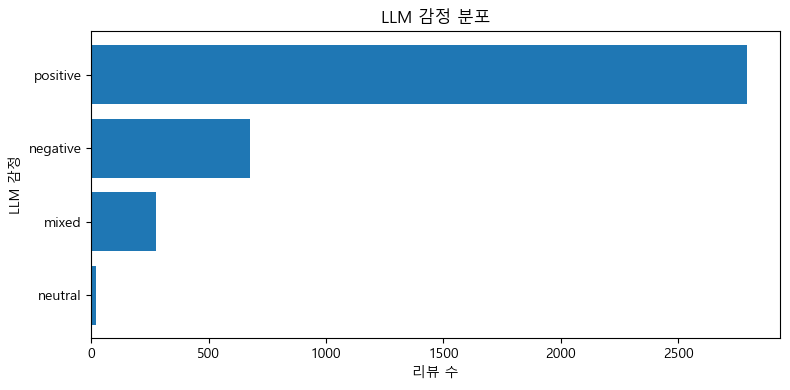

In [12]:
# ============================================================
# 전체 LLM 감정 분포 그래프
# ============================================================
llm_sentiment = (
    review_df["llm_sentiment"]
    .value_counts()
    .reset_index()
)
llm_sentiment.columns = ["llm_sentiment", "review_count"]

plot_df = llm_sentiment.sort_values("review_count", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["llm_sentiment"], plot_df["review_count"])
plt.title("LLM 감정 분포")
plt.xlabel("리뷰 수")
plt.ylabel("LLM 감정")
plt.tight_layout()
plt.show()

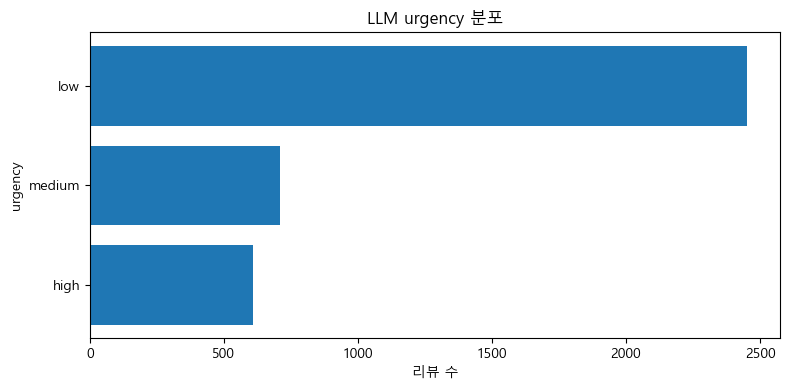

In [13]:
# ============================================================
# 전체 urgency 분포 그래프
# ============================================================
urgency_count = (
    review_df["urgency"]
    .value_counts()
    .reset_index()
)
urgency_count.columns = ["urgency", "review_count"]

plot_df = urgency_count.sort_values("review_count", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["urgency"], plot_df["review_count"])
plt.title("LLM urgency 분포")
plt.xlabel("리뷰 수")
plt.ylabel("urgency")
plt.tight_layout()
plt.show()

# 7. 유저가 긍정적으로 평가한 요소

긍정 요소도 태그 수가 아니라 **몇 개 게임에서 반복적으로 나타났는지**를 기준으로 본다.

In [14]:
# ============================================================
# 긍정 요소 TOP 10
# ============================================================
positive_issue_summary = issue_summary[
    (issue_summary["positive_game_count"] > 0) &
    (~issue_summary[ISSUE_COL].str.lower().isin([x.lower() for x in positive_exclude_keywords]))
].copy()

positive_top = positive_issue_summary.sort_values(
    ["positive_game_count", "issue_game_count"],
    ascending=False
).head(TOP_N)

positive_top_display = positive_top[[
    ISSUE_COL,
    "positive_game_count",
    "issue_game_count",
    "issue_game_ratio",
    "total_issue_tag_count"
]].copy()

positive_top_display.columns = [
    "긍정 요소",
    "긍정 발생 게임 수",
    "전체 발생 게임 수",
    "발생 게임 비율(%)",
    "태그 수(참고)"
]

display(positive_top_display)

,긍정 요소,긍정 발생 게임 수,전체 발생 게임 수,발생 게임 비율(%),태그 수(참고)
3,게임플레이 루프,81,106,70.2,959
5,그래픽/사운드,69,89,58.9,432
8,난이도,45,76,50.3,328
1,가격/가치,45,68,45.0,148
15,스토리,36,48,31.8,358
19,콘텐츠 분량,35,85,56.3,415
0,UI/UX,24,85,56.3,336
2,개발사 소통,22,32,21.2,70
17,조작감,15,62,41.1,223
7,기타,12,61,40.4,191


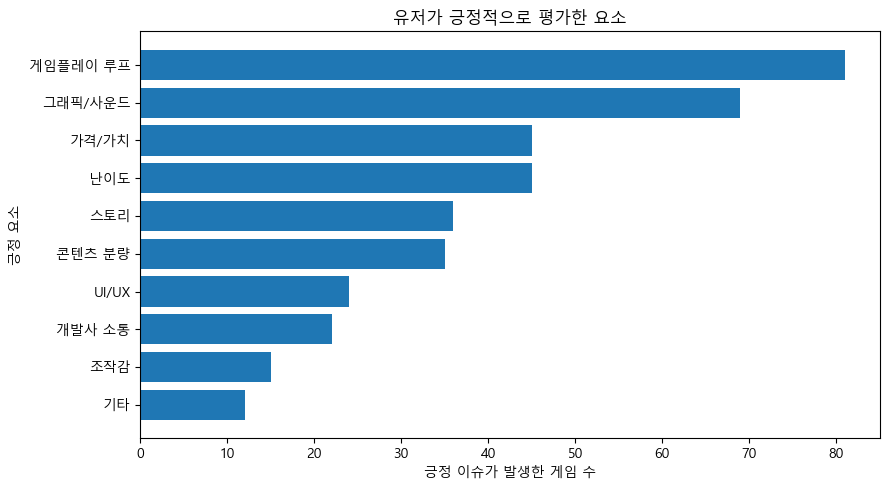

In [15]:
# ============================================================
# 긍정 요소 그래프
# ============================================================
plot_df = positive_top_display.sort_values("긍정 발생 게임 수")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["긍정 요소"], plot_df["긍정 발생 게임 수"])
plt.title("유저가 긍정적으로 평가한 요소")
plt.xlabel("긍정 이슈가 발생한 게임 수")
plt.ylabel("긍정 요소")
plt.tight_layout()
plt.show()

# 8. 유저가 부정적으로 평가한 리스크

부정 이슈도 **몇 개 게임에서 반복적으로 나타났는지**를 기준으로 본다.

In [16]:
# ============================================================
# 부정 리스크 TOP 10
# ============================================================
negative_top = issue_summary.sort_values(
    ["negative_game_count", "high_urgency_game_count", "issue_game_count"],
    ascending=False
).head(TOP_N)

negative_top_display = negative_top[[
    ISSUE_COL,
    "negative_game_count",
    "high_urgency_game_count",
    "issue_game_count",
    "issue_game_ratio",
    "total_issue_tag_count"
]].copy()

negative_top_display.columns = [
    "부정 리스크",
    "부정 발생 게임 수",
    "High urgency 발생 게임 수",
    "전체 발생 게임 수",
    "발생 게임 비율(%)",
    "태그 수(참고)"
]

display(negative_top_display)

,부정 리스크,부정 발생 게임 수,High urgency 발생 게임 수,전체 발생 게임 수,발생 게임 비율(%),태그 수(참고)
3,게임플레이 루프,80,56,106,70.2,959
0,UI/UX,77,46,85,56.3,336
11,버그,61,47,62,41.1,286
19,콘텐츠 분량,60,27,85,56.3,415
17,조작감,53,46,62,41.1,223
5,그래픽/사운드,52,41,89,58.9,432
8,난이도,49,33,76,50.3,328
7,기타,40,22,61,40.4,191
10,밸런스,38,28,45,29.8,170
1,가격/가치,33,20,68,45.0,148


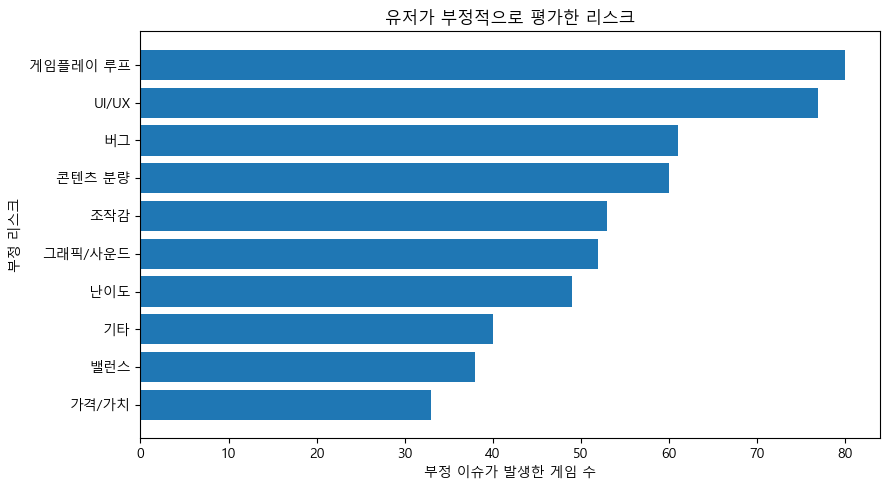

In [17]:
# ============================================================
# 부정 리스크 그래프
# ============================================================
plot_df = negative_top_display.sort_values("부정 발생 게임 수")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["부정 리스크"], plot_df["부정 발생 게임 수"])
plt.title("유저가 부정적으로 평가한 리스크")
plt.xlabel("부정 이슈가 발생한 게임 수")
plt.ylabel("부정 리스크")
plt.tight_layout()
plt.show()

# 9. 긍정과 부정이 함께 나타나는 핵심 평가 축

같은 이슈가 긍정과 부정 양쪽에서 모두 나타난다면,  
그 요소는 단순한 장점/단점이 아니라 **출시 전 조정이 필요한 핵심 평가 축**으로 볼 수 있다.

In [18]:
# ============================================================
# 긍정과 부정이 함께 나타나는 이슈
# ============================================================
both_issue = issue_summary[
    issue_summary["both_positive_negative_game_count"] > 0
].copy()

both_issue = both_issue.sort_values(
    ["both_positive_negative_game_count", "issue_game_count"],
    ascending=False
).head(TOP_N)

both_issue_display = both_issue[[
    ISSUE_COL,
    "positive_game_count",
    "negative_game_count",
    "both_positive_negative_game_count",
    "issue_game_count"
]].copy()

both_issue_display.columns = [
    "이슈",
    "긍정 발생 게임 수",
    "부정 발생 게임 수",
    "긍정/부정 공통 발생 게임 수",
    "전체 발생 게임 수"
]

display(both_issue_display)

,이슈,긍정 발생 게임 수,부정 발생 게임 수,긍정/부정 공통 발생 게임 수,전체 발생 게임 수
3,게임플레이 루프,81,80,61,106
5,그래픽/사운드,69,52,35,89
8,난이도,45,49,26,76
19,콘텐츠 분량,35,60,24,85
0,UI/UX,24,77,17,85
15,스토리,36,28,17,48
1,가격/가치,45,33,12,68
17,조작감,15,53,9,62
9,멀티/네트워크,10,16,7,20
11,버그,7,61,6,62


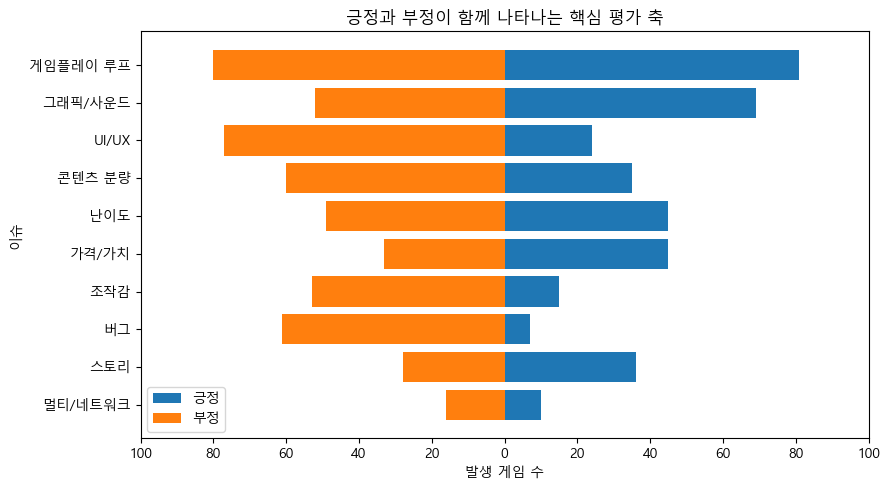

In [19]:
# ============================================================
# 긍정/부정이 함께 나타나는 이슈 그래프
# ============================================================
plot_df = both_issue_display.sort_values("전체 발생 게임 수", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["이슈"], plot_df["긍정 발생 게임 수"], label="긍정")
plt.barh(plot_df["이슈"], -plot_df["부정 발생 게임 수"], label="부정")

plt.title("긍정과 부정이 함께 나타나는 핵심 평가 축")
plt.xlabel("발생 게임 수")
plt.ylabel("이슈")
plt.legend()

current_ticks = plt.xticks()[0]
new_labels = [abs(int(tick)) for tick in current_ticks]
plt.xticks(current_ticks, new_labels)

plt.tight_layout()
plt.show()

# 10. High urgency 기준 출시 전 리스크

`High urgency`는 LLM이 리뷰 내용을 보고 시급도가 높다고 분류한 값이다.  
따라서 여러 게임에서 High urgency로 반복된 이슈는 출시 전 우선 점검 후보로 볼 수 있다.

In [20]:
# ============================================================
# High urgency 이슈 TOP 10
# ============================================================
high_top = issue_summary.sort_values(
    ["high_urgency_game_count", "negative_game_count", "issue_game_count"],
    ascending=False
).head(TOP_N)

high_top_display = high_top[[
    ISSUE_COL,
    "high_urgency_game_count",
    "negative_game_count",
    "issue_game_count",
    "issue_game_ratio"
]].copy()

high_top_display.columns = [
    "High urgency 이슈",
    "High urgency 발생 게임 수",
    "부정 발생 게임 수",
    "전체 발생 게임 수",
    "발생 게임 비율(%)"
]

display(high_top_display)

,High urgency 이슈,High urgency 발생 게임 수,부정 발생 게임 수,전체 발생 게임 수,발생 게임 비율(%)
3,게임플레이 루프,56,80,106,70.2
11,버그,47,61,62,41.1
0,UI/UX,46,77,85,56.3
17,조작감,46,53,62,41.1
6,긍정 칭찬,45,0,138,91.4
5,그래픽/사운드,41,52,89,58.9
8,난이도,33,49,76,50.3
10,밸런스,28,38,45,29.8
19,콘텐츠 분량,27,60,85,56.3
7,기타,22,40,61,40.4


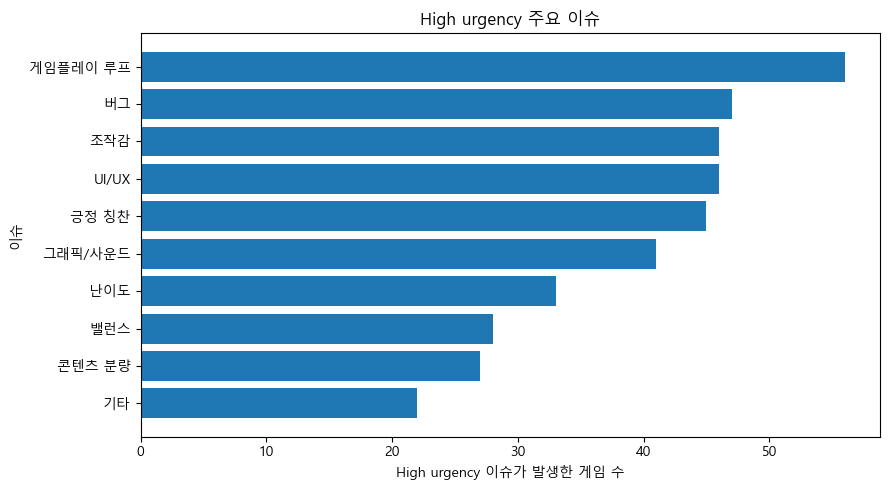

In [21]:
# ============================================================
# High urgency 주요 이슈 그래프
# ============================================================
plot_df = high_top_display.sort_values("High urgency 발생 게임 수")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["High urgency 이슈"], plot_df["High urgency 발생 게임 수"])
plt.title("High urgency 주요 이슈")
plt.xlabel("High urgency 이슈가 발생한 게임 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

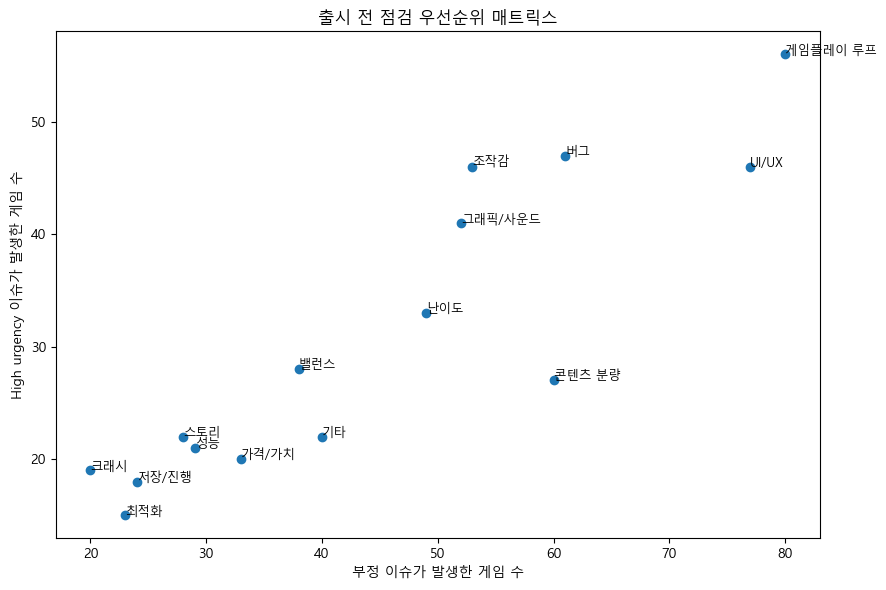

In [22]:
# ============================================================
# 출시 전 점검 우선순위 매트릭스
# ============================================================
# x축: 부정 발생 게임 수
# y축: High urgency 발생 게임 수

priority_table = issue_summary.sort_values(
    ["negative_game_count", "high_urgency_game_count", "issue_game_count"],
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))
plt.scatter(
    priority_table["negative_game_count"],
    priority_table["high_urgency_game_count"]
)

for i in range(len(priority_table)):
    plt.text(
        priority_table["negative_game_count"].iloc[i],
        priority_table["high_urgency_game_count"].iloc[i],
        priority_table[ISSUE_COL].iloc[i],
        fontsize=9
    )

plt.title("출시 전 점검 우선순위 매트릭스")
plt.xlabel("부정 이슈가 발생한 게임 수")
plt.ylabel("High urgency 이슈가 발생한 게임 수")
plt.tight_layout()
plt.show()

# 11. 조건별 분석 준비

가격대, 장르, Steam 태그, 플레이 방식별로 반복 이슈를 보기 위해  
게임 단위 메타데이터를 만든다.

,플레이 방식,리뷰 수
0,Single-player 중심,3159
1,멀티/협동 요소 포함,611


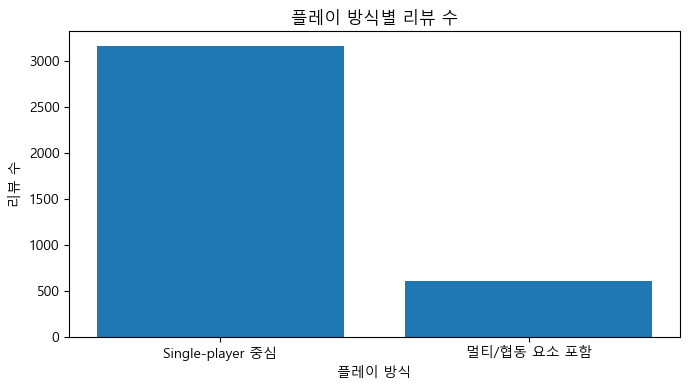

In [23]:
# ============================================================
# 플레이 방식 간단 분류
# ============================================================
# categories_text에 Co-op, Multi-player, Online이 들어가면
# 멀티/협동 요소가 있는 게임으로 분류한다.

review_df["categories_text"] = review_df["categories_text"].fillna("").astype(str)

review_df["play_style"] = "Single-player 중심"
review_df.loc[
    review_df["categories_text"].str.contains("Co-op|Multi-player|Online", case=False, regex=True),
    "play_style"
] = "멀티/협동 요소 포함"

tag_df = tag_df.merge(
    review_df[["recommendationid", "play_style"]].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

play_sample = (
    review_df
    .groupby("play_style")["recommendationid"]
    .nunique()
    .reset_index()
)
play_sample.columns = ["플레이 방식", "리뷰 수"]

display(play_sample)

plt.figure(figsize=(7, 4))
plt.bar(play_sample["플레이 방식"], play_sample["리뷰 수"])
plt.title("플레이 방식별 리뷰 수")
plt.xlabel("플레이 방식")
plt.ylabel("리뷰 수")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 게임 단위 메타데이터 만들기
# ============================================================
game_meta = (
    review_df[[
        GAME_ID_COL,
        GAME_NAME_COL,
        "price_group",
        "genres_text",
        "categories_text",
        "top_steam_tags_text",
        "play_style"
    ]]
    .drop_duplicates(GAME_ID_COL)
    .copy()
)

game_issue_meta_df = game_issue_df.merge(
    game_meta,
    on=[GAME_ID_COL, GAME_NAME_COL],
    how="left"
)

print("게임 메타데이터:", game_meta.shape)
print("게임-이슈 메타데이터:", game_issue_meta_df.shape)
display(game_issue_meta_df.head())

게임 메타데이터: (151, 7)
게임-이슈 메타데이터: (1160, 19)


,appid,game_name,issue_name_kor,issue_review_count,issue_tag_count,positive_review_count,negative_review_count,mixed_review_count,high_urgency_review_count,positive_present,negative_present,mixed_present,high_urgency_present,both_positive_negative_present,price_group,genres_text,categories_text,top_steam_tags_text,play_style
0,571740,Golf It!,UI/UX,4,4,0,4,0,2,False,True,False,True,False,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함
1,571740,Golf It!,가격/가치,1,1,1,0,0,0,True,False,False,False,False,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함
2,571740,Golf It!,게임플레이 루프,6,6,3,3,0,2,True,True,False,True,True,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함
3,571740,Golf It!,그래픽/사운드,5,5,2,3,0,0,True,True,False,False,True,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함
4,571740,Golf It!,긍정 칭찬,29,29,29,0,0,0,True,False,False,False,False,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함


# 12. 가격대별 주요 반응 차이

가격대별로 어떤 긍정 요소와 부정 이슈가 반복되는지 확인한다.  
값은 **해당 가격대 게임 중 그 이슈가 나타난 게임 비율**이다.

,가격대,게임 수
0,free,1
1,0-5,54
2,5-10,39
3,10-20,45
4,20-40,11
5,40+,1


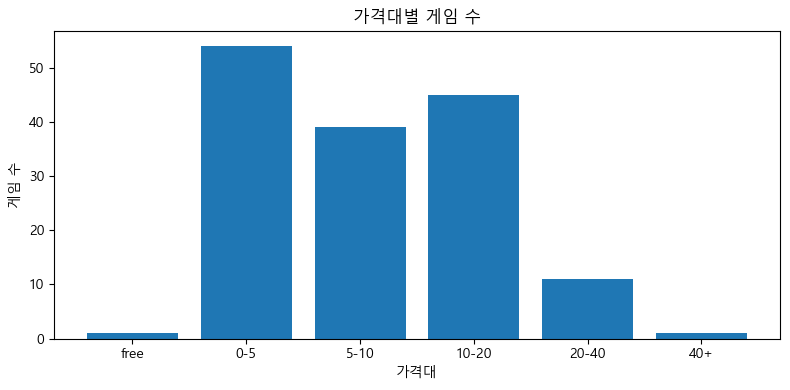

In [25]:
# ============================================================
# 가격대별 표본 게임 수
# ============================================================
price_sample = (
    game_meta
    .groupby("price_group")[GAME_ID_COL]
    .nunique()
    .reindex(price_group_order)
    .dropna()
    .reset_index()
)
price_sample.columns = ["가격대", "게임 수"]

display(price_sample)

plt.figure(figsize=(8, 4))
plt.bar(price_sample["가격대"], price_sample["게임 수"])
plt.title("가격대별 게임 수")
plt.xlabel("가격대")
plt.ylabel("게임 수")
plt.tight_layout()
plt.show()

[가격대별 주요 긍정 요소 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,11.1,27.8,7.4,42.6,37.0,3.7,25.9,18.5,9.3,14.8
10-20,20.0,37.8,17.8,64.4,57.8,13.3,37.8,33.3,15.6,31.1
20-40,18.2,45.5,27.3,81.8,54.5,0.0,45.5,36.4,0.0,36.4
40+,0.0,0.0,0.0,100.0,100.0,0.0,0.0,100.0,0.0,0.0
5-10,17.9,20.5,17.9,48.7,41.0,10.3,23.1,15.4,7.7,23.1
free,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


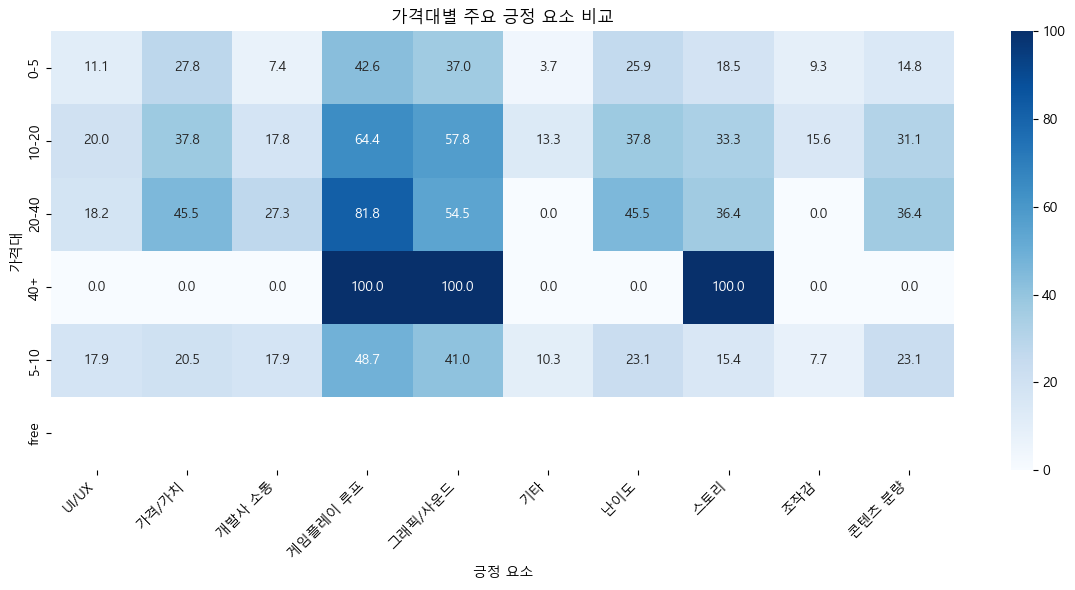

In [26]:
# ============================================================
# 가격대별 주요 긍정 요소 히트맵
# ============================================================
top_positive_issues = positive_top[ISSUE_COL].tolist()

price_positive = game_issue_meta_df[
    (game_issue_meta_df["positive_present"]) &
    (game_issue_meta_df[ISSUE_COL].isin(top_positive_issues))
].copy()

price_positive_count = (
    price_positive
    .groupby(["price_group", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

price_game_count = game_meta.groupby("price_group")[GAME_ID_COL].nunique()

price_positive_pivot = price_positive_count.pivot_table(
    index="price_group",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(price_group_order).dropna(how="all")

price_positive_rate = price_positive_pivot.div(price_game_count, axis=0) * 100

print("[가격대별 주요 긍정 요소 발생 게임 비율(%)]")
display(price_positive_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(price_positive_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("가격대별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[가격대별 주요 부정 이슈 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,31.5,11.1,38.9,27.8,16.7,18.5,14.8,27.8,24.1,31.5
10-20,68.9,28.9,71.1,42.2,40.0,48.9,31.1,46.7,48.9,44.4
20-40,81.8,36.4,81.8,63.6,36.4,54.5,36.4,63.6,54.5,45.5
40+,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5-10,48.7,23.1,43.6,25.6,20.5,25.6,28.2,43.6,28.2,41.0
free,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


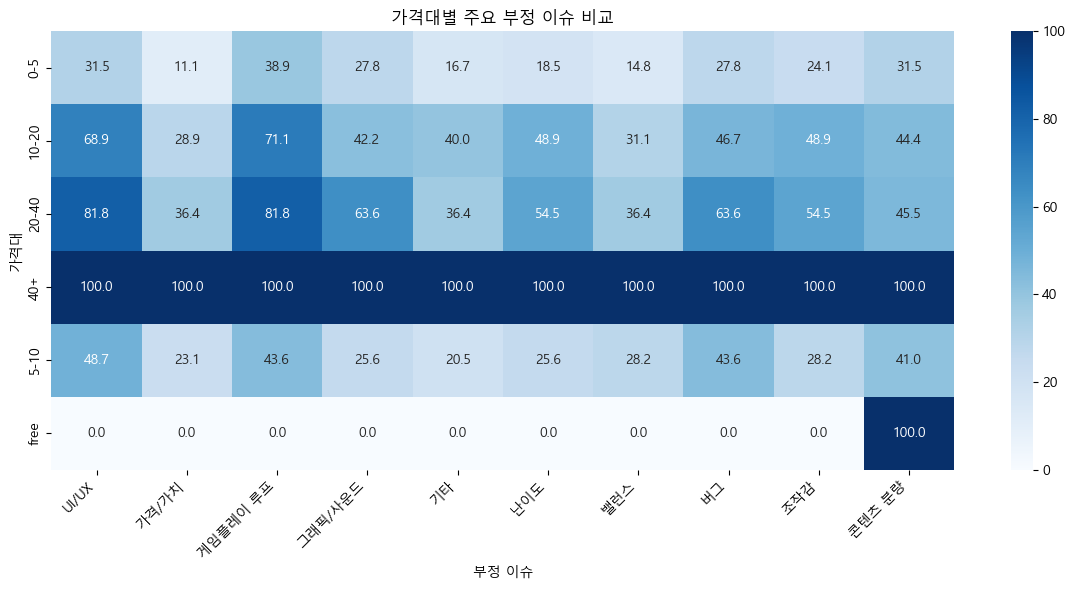

In [27]:
# ============================================================
# 가격대별 주요 부정 이슈 히트맵
# ============================================================
top_negative_issues = negative_top[ISSUE_COL].tolist()

price_negative = game_issue_meta_df[
    (game_issue_meta_df["negative_present"]) &
    (game_issue_meta_df[ISSUE_COL].isin(top_negative_issues))
].copy()

price_negative_count = (
    price_negative
    .groupby(["price_group", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

price_negative_pivot = price_negative_count.pivot_table(
    index="price_group",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(price_group_order).dropna(how="all")

price_negative_rate = price_negative_pivot.div(price_game_count, axis=0) * 100

print("[가격대별 주요 부정 이슈 발생 게임 비율(%)]")
display(price_negative_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(price_negative_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("가격대별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 13. 장르별 주요 반응 차이

`genres_text`를 펼쳐서 장르별 반복 이슈를 확인한다.

,genre,게임 수
0,Indie,151
1,Adventure,82
2,Casual,68
3,Action,62
4,Simulation,42
5,RPG,32
6,Strategy,26
7,Racing,12
8,Sports,8


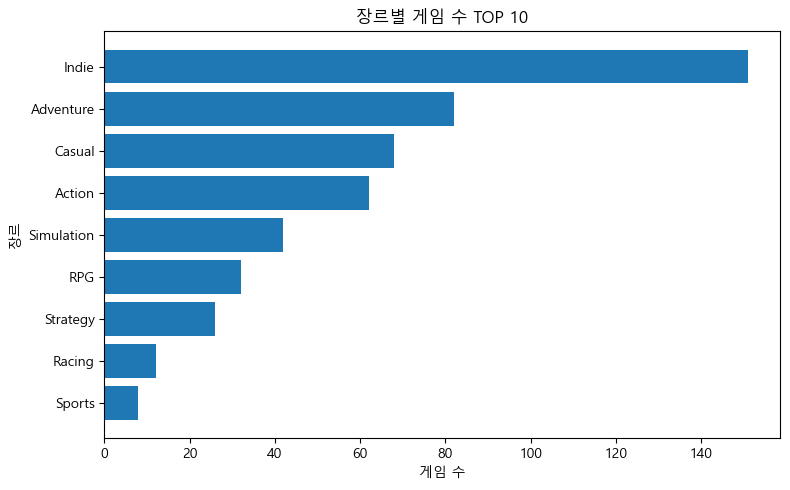

In [28]:
# ============================================================
# 장르 펼치기
# ============================================================
game_genre_df = game_meta[[GAME_ID_COL, GAME_NAME_COL, "genres_text"]].copy()
game_genre_df["genre"] = game_genre_df["genres_text"].fillna("").astype(str).str.split(",")
game_genre_df = game_genre_df.explode("genre")
game_genre_df["genre"] = game_genre_df["genre"].astype(str).str.strip()
game_genre_df = game_genre_df[game_genre_df["genre"] != ""]

genre_sample = (
    game_genre_df
    .groupby("genre")[GAME_ID_COL]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="게임 수")
)

top_genres = genre_sample.head(8)["genre"].tolist()

display(genre_sample.head(15))

plt.figure(figsize=(8, 5))
plot_df = genre_sample.head(10).sort_values("게임 수")
plt.barh(plot_df["genre"], plot_df["게임 수"])
plt.title("장르별 게임 수 TOP 10")
plt.xlabel("게임 수")
plt.ylabel("장르")
plt.tight_layout()
plt.show()

[장르별 주요 긍정 요소 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
genre,,,,,,,,,,
Action,16.1,27.4,12.9,54.8,41.9,8.1,35.5,16.1,11.3,21.0
Adventure,13.4,30.5,11.0,53.7,47.6,4.9,31.7,31.7,7.3,24.4
Casual,16.2,30.9,13.2,45.6,36.8,7.4,19.1,14.7,8.8,23.5
Indie,15.9,29.8,14.6,53.6,45.7,7.9,29.8,23.8,9.9,23.2
RPG,6.2,34.4,15.6,50.0,37.5,3.1,28.1,21.9,6.2,15.6
Racing,16.7,33.3,16.7,50.0,50.0,33.3,25.0,8.3,41.7,25.0
Simulation,9.5,26.2,11.9,54.8,26.2,4.8,19.0,4.8,7.1,28.6
Sports,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Strategy,11.5,26.9,11.5,61.5,38.5,3.8,34.6,11.5,0.0,19.2


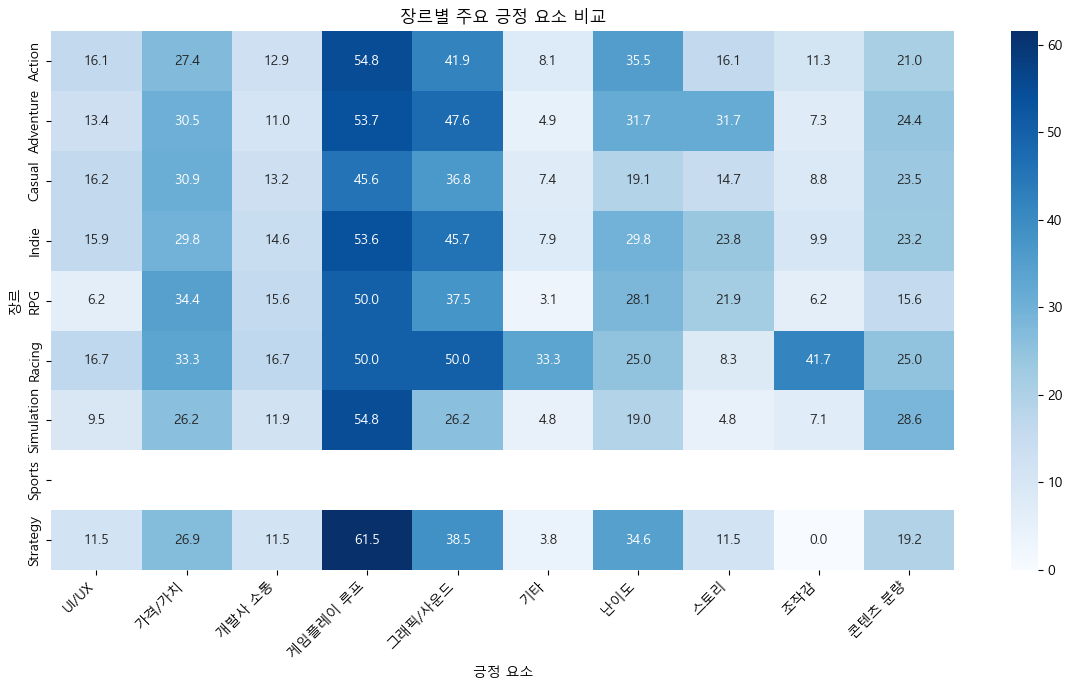

In [29]:
# ============================================================
# 장르별 주요 긍정 요소 히트맵
# ============================================================
genre_issue_df = game_issue_df.merge(
    game_genre_df[[GAME_ID_COL, "genre"]],
    on=GAME_ID_COL,
    how="left"
)

genre_positive = genre_issue_df[
    (genre_issue_df["positive_present"]) &
    (genre_issue_df["genre"].isin(top_genres)) &
    (genre_issue_df[ISSUE_COL].isin(top_positive_issues))
].copy()

genre_positive_count = (
    genre_positive
    .groupby(["genre", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

genre_game_count = game_genre_df.groupby("genre")[GAME_ID_COL].nunique()

genre_positive_pivot = genre_positive_count.pivot_table(
    index="genre",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(top_genres)

genre_positive_rate = genre_positive_pivot.div(genre_game_count, axis=0) * 100

print("[장르별 주요 긍정 요소 발생 게임 비율(%)]")
display(genre_positive_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(genre_positive_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("장르별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("장르")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[장르별 주요 부정 이슈 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,조작감,콘텐츠 분량
genre,,,,,,,,,,
Action,51.6,24.2,56.5,35.5,29.0,33.9,25.8,41.9,46.8,35.5
Adventure,50.0,25.6,51.2,39.0,25.6,36.6,24.4,41.5,42.7,43.9
Casual,50.0,16.2,45.6,33.8,26.5,25.0,14.7,42.6,29.4,44.1
Indie,51.0,21.9,53.0,34.4,26.5,32.5,25.2,40.4,35.1,39.7
RPG,56.2,31.2,65.6,28.1,37.5,34.4,40.6,56.2,31.2,43.8
Racing,50.0,25.0,58.3,41.7,16.7,50.0,33.3,58.3,41.7,41.7
Simulation,54.8,23.8,61.9,35.7,28.6,26.2,26.2,42.9,31.0,57.1
Sports,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Strategy,65.4,23.1,53.8,26.9,30.8,34.6,42.3,42.3,23.1,38.5


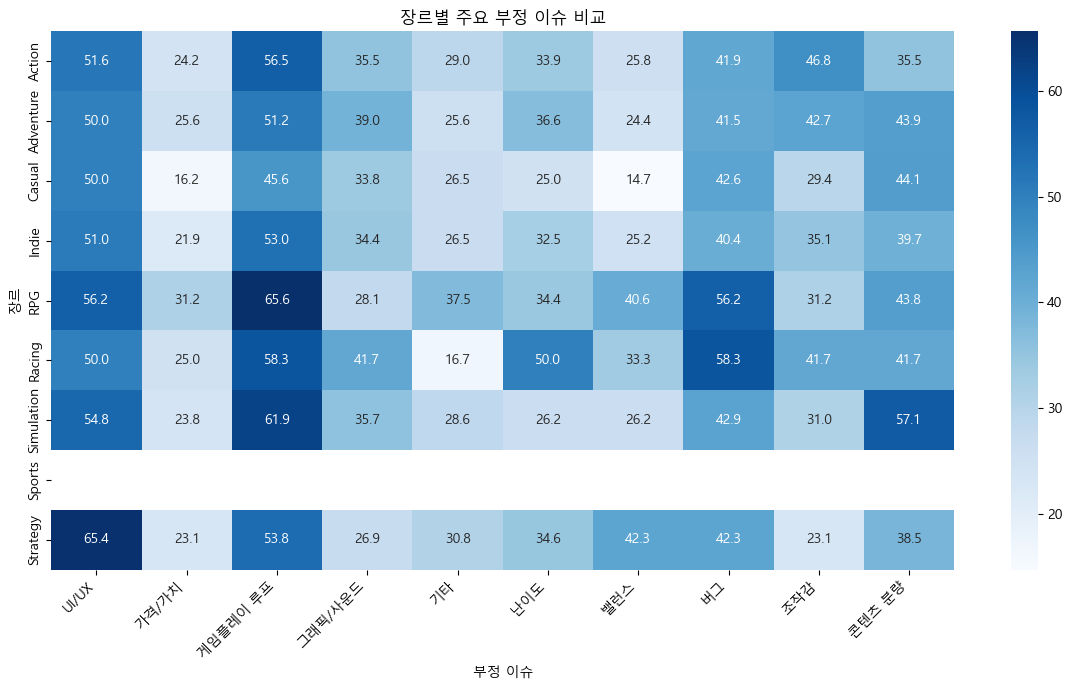

In [30]:
# ============================================================
# 장르별 주요 부정 이슈 히트맵
# ============================================================
genre_negative = genre_issue_df[
    (genre_issue_df["negative_present"]) &
    (genre_issue_df["genre"].isin(top_genres)) &
    (genre_issue_df[ISSUE_COL].isin(top_negative_issues))
].copy()

genre_negative_count = (
    genre_negative
    .groupby(["genre", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

genre_negative_pivot = genre_negative_count.pivot_table(
    index="genre",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(top_genres)

genre_negative_rate = genre_negative_pivot.div(genre_game_count, axis=0) * 100

print("[장르별 주요 부정 이슈 발생 게임 비율(%)]")
display(genre_negative_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(genre_negative_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("장르별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("장르")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 14. Steam 태그별 주요 반응 차이

`top_steam_tags_text`를 펼쳐서 Steam 태그별 반복 이슈를 확인한다.

,steam_tag,게임 수
0,Adventure,49
1,Casual,48
2,Action,44
3,Indie,39
4,Exploration,37
5,Puzzle,36
6,2D,34
7,Singleplayer,33
8,Simulation,28
9,3D,27


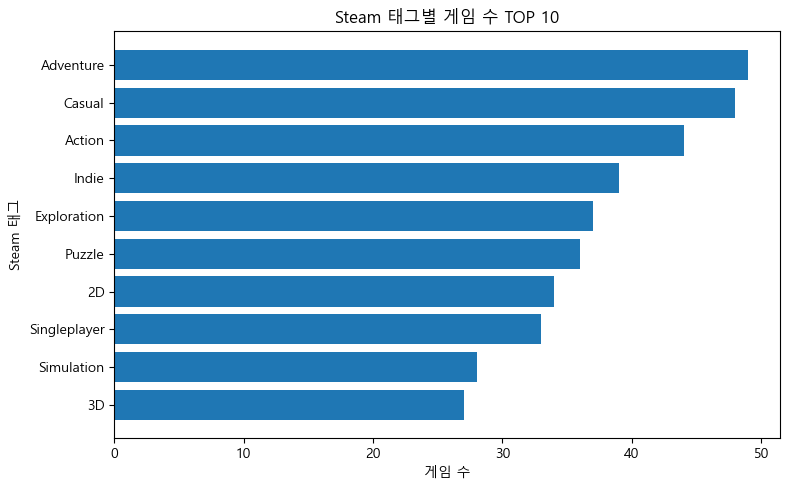

In [31]:
# ============================================================
# Steam 태그 펼치기
# ============================================================
game_steam_tag_df = game_meta[[GAME_ID_COL, GAME_NAME_COL, "top_steam_tags_text"]].copy()
game_steam_tag_df["steam_tag"] = game_steam_tag_df["top_steam_tags_text"].fillna("").astype(str).str.split(",")
game_steam_tag_df = game_steam_tag_df.explode("steam_tag")
game_steam_tag_df["steam_tag"] = game_steam_tag_df["steam_tag"].astype(str).str.strip()
game_steam_tag_df = game_steam_tag_df[game_steam_tag_df["steam_tag"] != ""]

steam_tag_sample = (
    game_steam_tag_df
    .groupby("steam_tag")[GAME_ID_COL]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="게임 수")
)

top_steam_tags = steam_tag_sample.head(10)["steam_tag"].tolist()

display(steam_tag_sample.head(15))

plt.figure(figsize=(8, 5))
plot_df = steam_tag_sample.head(10).sort_values("게임 수")
plt.barh(plot_df["steam_tag"], plot_df["게임 수"])
plt.title("Steam 태그별 게임 수 TOP 10")
plt.xlabel("게임 수")
plt.ylabel("Steam 태그")
plt.tight_layout()
plt.show()

[Steam 태그별 주요 긍정 요소 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
1980s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990's,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.5D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2D,23.5,26.5,11.8,50.0,50.0,11.8,50.0,26.5,8.8,23.5
2D Platformer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
Wholesome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Word Game,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
World War II,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


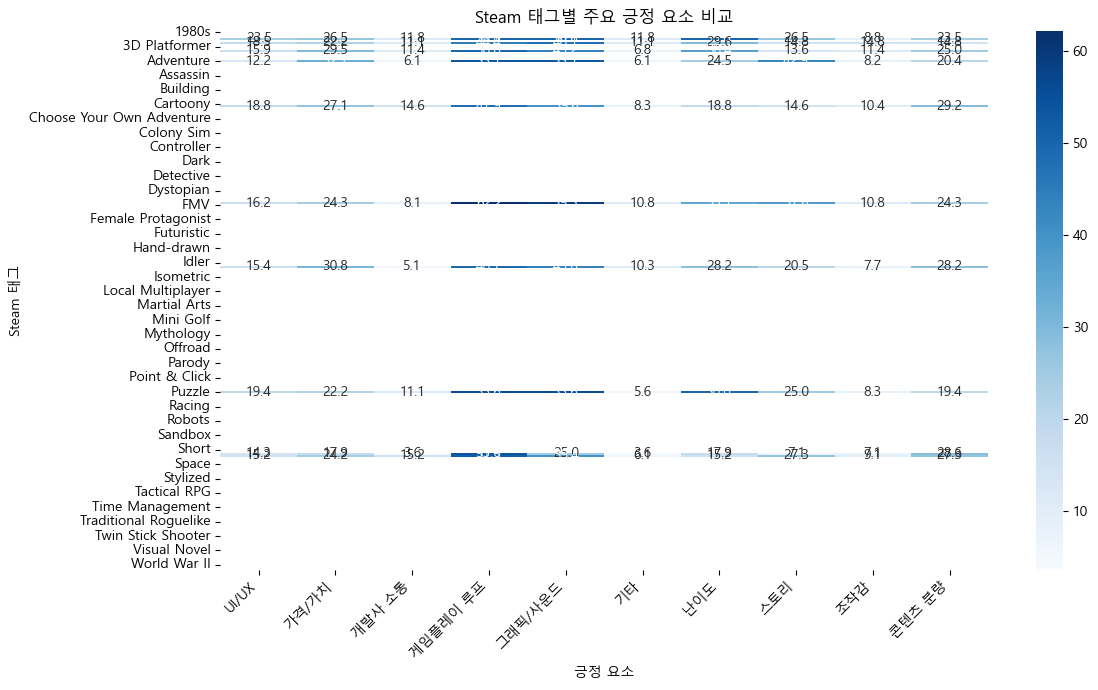

In [32]:
# ============================================================
# Steam 태그별 주요 긍정 요소 히트맵
# ============================================================
steam_tag_issue_df = game_issue_df.merge(
    game_steam_tag_df[[GAME_ID_COL, "steam_tag"]],
    on=GAME_ID_COL,
    how="left"
)

steam_positive = steam_tag_issue_df[
    (steam_tag_issue_df["positive_present"]) &
    (steam_tag_issue_df["steam_tag"].isin(top_steam_tags)) &
    (steam_tag_issue_df[ISSUE_COL].isin(top_positive_issues))
].copy()

steam_positive_count = (
    steam_positive
    .groupby(["steam_tag", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

steam_tag_game_count = game_steam_tag_df.groupby("steam_tag")[GAME_ID_COL].nunique()

steam_positive_pivot = steam_positive_count.pivot_table(
    index="steam_tag",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(top_steam_tags)

steam_positive_rate = steam_positive_pivot.div(steam_tag_game_count, axis=0) * 100

print("[Steam 태그별 주요 긍정 요소 발생 게임 비율(%)]")
display(steam_positive_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(steam_positive_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("Steam 태그별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[Steam 태그별 주요 부정 이슈 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
1980s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990's,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.5D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2D,52.9,8.8,50.0,14.7,14.7,29.4,20.6,29.4,20.6,35.3
2D Platformer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
Wholesome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Word Game,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
World War II,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


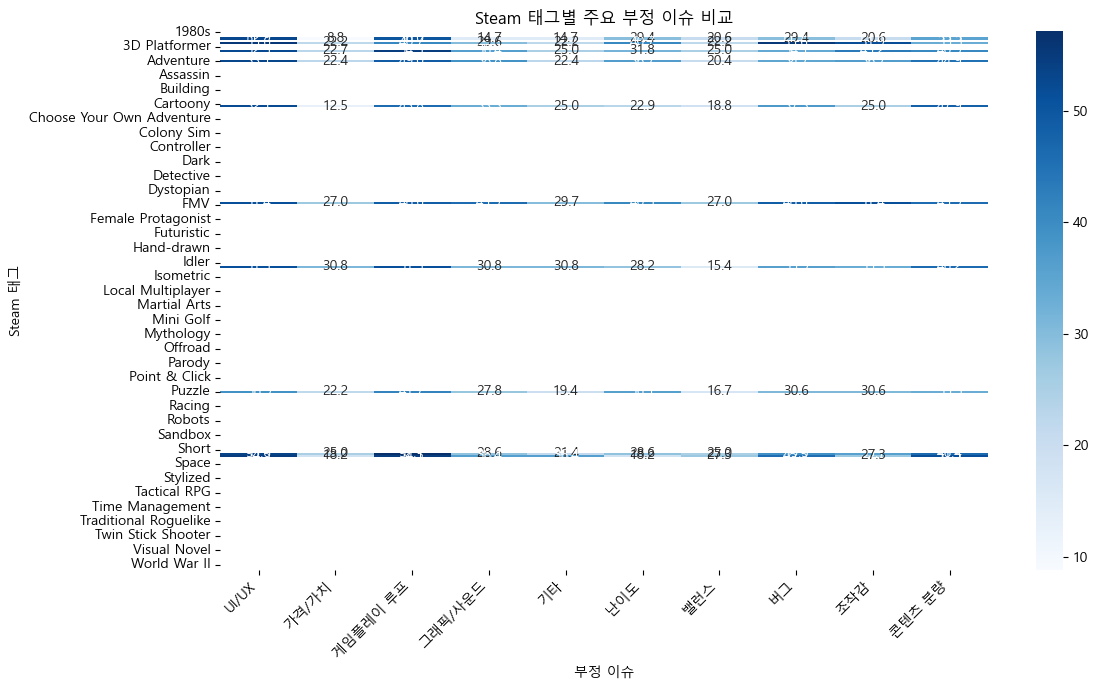

In [33]:
# ============================================================
# Steam 태그별 주요 부정 이슈 히트맵
# ============================================================
steam_negative = steam_tag_issue_df[
    (steam_tag_issue_df["negative_present"]) &
    (steam_tag_issue_df["steam_tag"].isin(top_steam_tags)) &
    (steam_tag_issue_df[ISSUE_COL].isin(top_negative_issues))
].copy()

steam_negative_count = (
    steam_negative
    .groupby(["steam_tag", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

steam_negative_pivot = steam_negative_count.pivot_table(
    index="steam_tag",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
).reindex(top_steam_tags)

steam_negative_rate = steam_negative_pivot.div(steam_tag_game_count, axis=0) * 100

print("[Steam 태그별 주요 부정 이슈 발생 게임 비율(%)]")
display(steam_negative_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(steam_negative_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("Steam 태그별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 15. 플레이 방식별 주요 반응 차이

플레이 방식은 간단하게 두 그룹으로 나눈다.

| 구분 | 기준 |
|---|---|
| Single-player 중심 | categories_text에 멀티/협동 관련 단어가 없는 경우 |
| 멀티/협동 요소 포함 | Co-op, Multi-player, Online이 포함된 경우 |

[플레이 방식별 주요 긍정 요소 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
play_style,,,,,,,,,,
Single-player 중심,14.5,27.4,12.9,52.4,49.2,7.3,30.6,29.0,8.1,21.0
멀티/협동 요소 포함,22.2,40.7,22.2,59.3,29.6,11.1,25.9,0.0,18.5,33.3


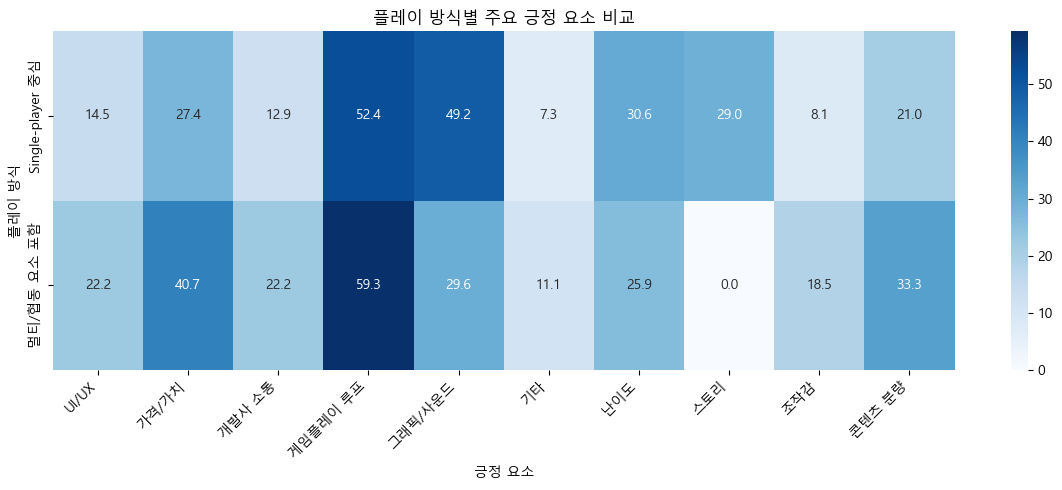

In [34]:
# ============================================================
# 플레이 방식별 주요 긍정 요소 히트맵
# ============================================================
play_issue_df = game_issue_meta_df.copy()

play_positive = play_issue_df[
    (play_issue_df["positive_present"]) &
    (play_issue_df[ISSUE_COL].isin(top_positive_issues))
].copy()

play_positive_count = (
    play_positive
    .groupby(["play_style", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

play_game_count = game_meta.groupby("play_style")[GAME_ID_COL].nunique()

play_positive_pivot = play_positive_count.pivot_table(
    index="play_style",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
)

play_positive_rate = play_positive_pivot.div(play_game_count, axis=0) * 100

print("[플레이 방식별 주요 긍정 요소 발생 게임 비율(%)]")
display(play_positive_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(play_positive_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("플레이 방식별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 플레이 방식별 주요 부정 이슈 히트맵
# ============================================================
play_negative = play_issue_df[
    (play_issue_df["negative_present"]) &
    (play_issue_df[ISSUE_COL].isin(top_negative_issues))
].copy()

play_negative_count = (
    play_negative
    .groupby(["play_style", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

play_negative_pivot = play_negative_count.pivot_table(
    index="play_style",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
)

play_negative_rate = play_negative_pivot.div(play_game_count, axis=0) * 100

print("[플레이 방식별 주요 부정 이슈 발생 게임 비율(%)]")
display(play_negative_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(play_negative_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("플레이 방식별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[플레이 방식별 주요 부정 이슈 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,조작감,콘텐츠 분량
play_style,,,,,,,,,,
Single-player 중심,50.8,24.2,50.0,32.3,25.0,31.5,25.8,39.5,33.9,41.1
멀티/협동 요소 포함,51.9,11.1,66.7,44.4,33.3,37.0,22.2,44.4,40.7,33.3


KeyboardInterrupt: 

# 16. 조원 EDA 아이디어 접목: 성과 등급별 Steam 태그 DNA 분석

조원 EDA 코드는 LLM 리뷰 이슈를 보는 분석이 아니라,  
**게임 메타데이터의 Steam 태그와 성과 등급을 비교하는 분석**이다.

핵심 질문은 다음과 같다.

> 성과가 좋은 게임들은 어떤 Steam 태그 조합을 자주 가지고 있는가?

여기서 사용하는 성과 등급은 `performance_grade`다.

| 등급 | 의미 |
|---|---|
| `high_high` | 판매 규모도 높고 긍정률도 높은 게임 |
| `high_mid` | 판매 규모는 높지만 긍정률은 중간인 게임 |
| `mid_high` | 판매 규모는 중간이지만 긍정률은 높은 게임 |

이 분석은 우리 LLM 이슈 분석과 직접 같은 분석은 아니지만,  
**개발자가 입력할 Steam 태그 조건을 정하거나, 성공 게임의 태그 조합을 참고하는 용도**로 접목할 수 있다.

In [ ]:
# ============================================================
# 조원 EDA 데이터 불러오기
# ============================================================
graded_df = pd.read_csv(GRADED_GAMES_PATH)
graded_df["appid"] = graded_df["appid"].astype(int)

def parse_tag_dict(tag_text):
    try:
        tag_dict = ast.literal_eval(str(tag_text))
        return list(tag_dict.keys())
    except Exception:
        return []

def parse_list_text(text):
    try:
        value = ast.literal_eval(str(text))
        return value
    except Exception:
        return []

graded_df["tag_list"] = graded_df["tags"].apply(parse_tag_dict)
graded_df["genre_list"] = graded_df["genres"].apply(parse_list_text)

grade_name_map = {
    "high_high": "HH: 판매 High / 긍정률 High",
    "high_mid": "HM: 판매 High / 긍정률 Mid",
    "mid_high": "MH: 판매 Mid / 긍정률 High"
}

target_grade_keys = list(grade_name_map.keys())
tier_df = graded_df[graded_df["performance_grade"].isin(target_grade_keys)].copy()
tier_df["performance_group"] = tier_df["performance_grade"].map(grade_name_map)

print("성과 등급 분석 대상 게임 수:", len(tier_df))
display(tier_df[["appid", "name", "performance_grade", "performance_group", "positive_rate", "total_reviews"]].head())

성과 등급 분석 대상 게임 수: 3098


,appid,name,performance_grade,performance_group,positive_rate,total_reviews
0,226620,Desktop Dungeons,high_high,HH: 판매 High / 긍정률 High,84.007030,2276
1,230210,ASYLUM,mid_high,MH: 판매 Mid / 긍정률 High,87.068966,348
2,251570,7 Days to Die,high_high,HH: 판매 High / 긍정률 High,88.607633,370046
4,269770,Secrets of Grindea,high_high,HH: 판매 High / 긍정률 High,89.334946,8270
7,290100,Bulwark: Falconeer Chronicles,high_high,HH: 판매 High / 긍정률 High,84.682332,1149


In [ ]:
# ============================================================
# 성과 등급별 핵심 Steam 태그 TOP 10
# ============================================================
common_tags = [
    "Indie", "Singleplayer", "2D", "3D", "Casual", "Early Access",
    "Action", "Adventure", "RPG", "Strategy", "Simulation"
]

rows = []

for grade, grade_name in grade_name_map.items():
    group_df = tier_df[tier_df["performance_grade"] == grade]
    total_games = len(group_df)

    all_tags = []
    for tags in group_df["tag_list"]:
        filtered_tags = [tag for tag in tags if tag not in common_tags]
        all_tags.extend(filtered_tags)

    tag_count = Counter(all_tags)

    for tag, count in tag_count.most_common(10):
        rows.append({
            "performance_grade": grade,
            "performance_group": grade_name,
            "steam_tag": tag,
            "tag_game_count": count,
            "tag_game_ratio": round(count / total_games * 100, 1)
        })

tier_tag_summary = pd.DataFrame(rows)

display(tier_tag_summary.head(30))

,performance_grade,performance_group,steam_tag,tag_game_count,tag_game_ratio
0,high_high,HH: 판매 High / 긍정률 High,Exploration,281,32.4
1,high_high,HH: 판매 High / 긍정률 High,Story Rich,277,32.0
2,high_high,HH: 판매 High / 긍정률 High,Atmospheric,262,30.3
3,high_high,HH: 판매 High / 긍정률 High,Pixel Graphics,233,26.9
4,high_high,HH: 판매 High / 긍정률 High,First-Person,220,25.4
5,high_high,HH: 판매 High / 긍정률 High,Cute,212,24.5
6,high_high,HH: 판매 High / 긍정률 High,Colorful,190,21.9
7,high_high,HH: 판매 High / 긍정률 High,Horror,171,19.7
8,high_high,HH: 판매 High / 긍정률 High,Funny,163,18.8
9,high_high,HH: 판매 High / 긍정률 High,Relaxing,155,17.9


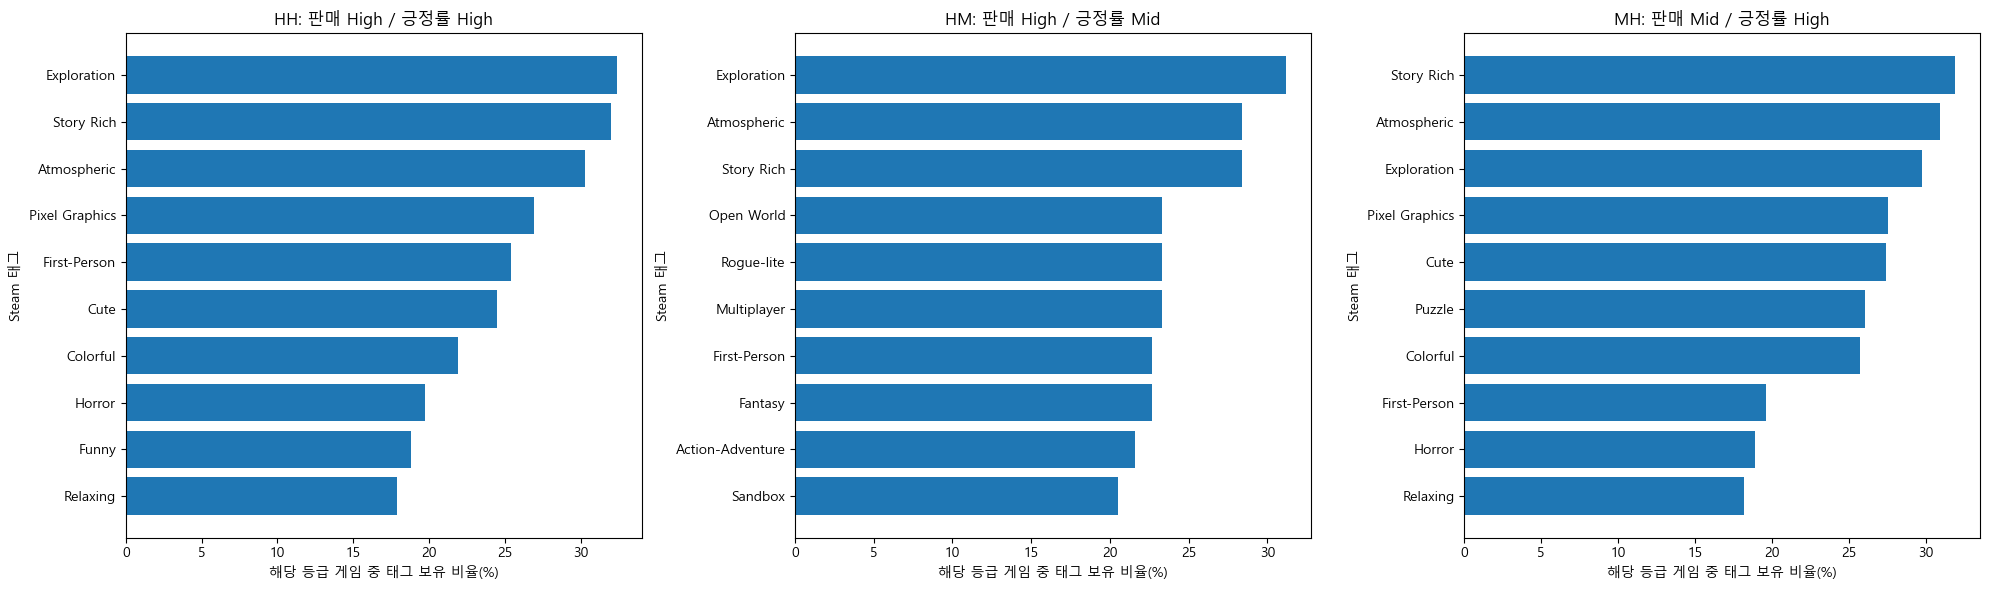

In [ ]:
# ============================================================
# 성과 등급별 핵심 Steam 태그 그래프
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (grade, grade_name) in enumerate(grade_name_map.items()):
    plot_df = tier_tag_summary[
        tier_tag_summary["performance_grade"] == grade
    ].sort_values("tag_game_ratio", ascending=True)

    axes[i].barh(plot_df["steam_tag"], plot_df["tag_game_ratio"])
    axes[i].set_title(grade_name)
    axes[i].set_xlabel("해당 등급 게임 중 태그 보유 비율(%)")
    axes[i].set_ylabel("Steam 태그")

plt.tight_layout()
plt.show()

## 조원 EDA의 분류 방식을 우리 코드에 접목할 수 있는가?

가능하다.  
조원 코드는 게임을 `performance_grade` 기준으로 분류한 뒤, 각 그룹의 Steam 태그 특징을 본다.

우리 분석에서는 이 등급을 LLM 이슈 분석 결과에 붙여서 다음 질문을 볼 수 있다.

> 성과 등급별로 반복되는 리뷰 이슈가 다른가?

즉, Steam 태그 DNA 분석은 메타데이터 기준이고,  
아래 코드는 그 분류를 LLM 반복 이슈 분석에 붙여보는 시도다.

In [ ]:
# ============================================================
# 성과 등급을 LLM 이슈 분석에 붙이기
# ============================================================
performance_meta = graded_df[[
    "appid",
    "performance_grade",
    "positive_rate",
    "total_reviews"
]].copy()

performance_meta["performance_group"] = performance_meta["performance_grade"].map(grade_name_map)

performance_issue_df = game_issue_df.merge(
    performance_meta,
    left_on=GAME_ID_COL,
    right_on="appid",
    how="inner"
)

performance_issue_df = performance_issue_df[
    performance_issue_df["performance_grade"].isin(target_grade_keys)
].copy()

performance_game_count = (
    performance_issue_df
    .groupby("performance_group")[GAME_ID_COL]
    .nunique()
)

print("성과 등급이 붙은 LLM 분석 게임 수:", performance_issue_df[GAME_ID_COL].nunique())
display(performance_game_count.reset_index(name="게임 수"))

성과 등급이 붙은 LLM 분석 게임 수: 64


,performance_group,게임 수
0,HH: 판매 High / 긍정률 High,29
1,HM: 판매 High / 긍정률 Mid,4
2,MH: 판매 Mid / 긍정률 High,31


[성과 등급별 주요 부정 이슈 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,조작감,콘텐츠 분량
performance_group,,,,,,,,,,
HH: 판매 High / 긍정률 High,75.9,44.8,86.2,58.6,58.6,58.6,58.6,69.0,58.6,72.4
HM: 판매 High / 긍정률 Mid,75.0,75.0,100.0,100.0,100.0,75.0,75.0,75.0,100.0,50.0
MH: 판매 Mid / 긍정률 High,58.1,12.9,58.1,32.3,22.6,41.9,16.1,45.2,29.0,51.6


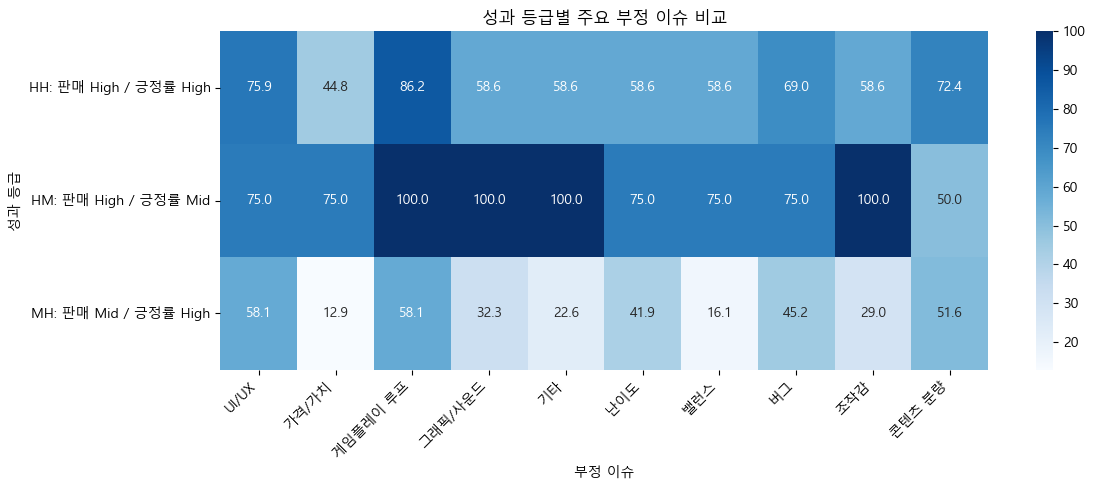

In [ ]:
# ============================================================
# 성과 등급별 반복 부정 이슈 비교
# ============================================================
performance_negative = performance_issue_df[
    (performance_issue_df["negative_present"]) &
    (performance_issue_df[ISSUE_COL].isin(top_negative_issues))
].copy()

performance_negative_count = (
    performance_negative
    .groupby(["performance_group", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

performance_negative_pivot = performance_negative_count.pivot_table(
    index="performance_group",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
)

performance_negative_rate = performance_negative_pivot.div(performance_game_count, axis=0) * 100

print("[성과 등급별 주요 부정 이슈 발생 게임 비율(%)]")
display(performance_negative_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(performance_negative_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("성과 등급별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("성과 등급")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[성과 등급별 주요 긍정 요소 발생 게임 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
performance_group,,,,,,,,,,
HH: 판매 High / 긍정률 High,10.3,55.2,31.0,75.9,58.6,13.8,41.4,34.5,17.2,51.7
HM: 판매 High / 긍정률 Mid,0.0,0.0,25.0,75.0,75.0,0.0,25.0,25.0,0.0,75.0
MH: 판매 Mid / 긍정률 High,32.3,38.7,16.1,61.3,61.3,19.4,38.7,29.0,16.1,45.2


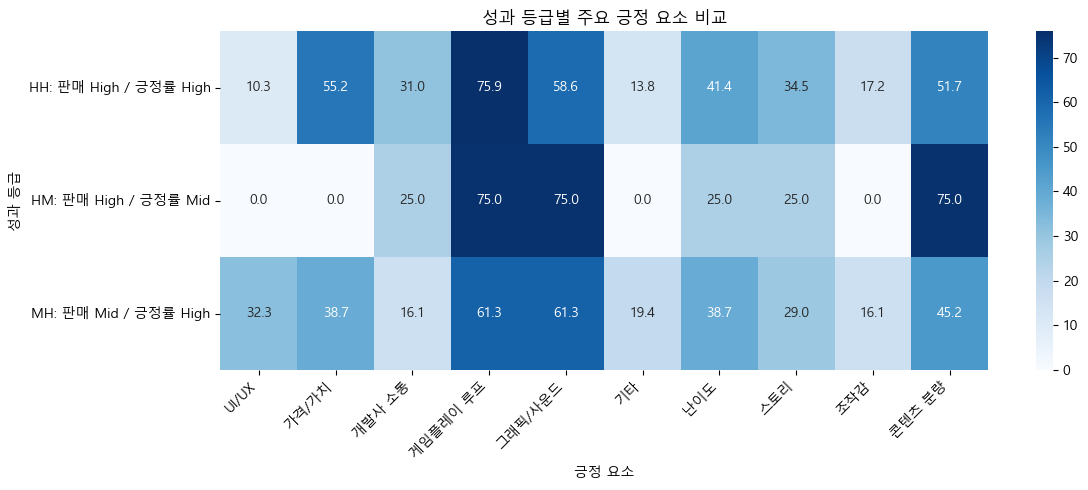

In [ ]:
# ============================================================
# 성과 등급별 반복 긍정 요소 비교
# ============================================================
performance_positive = performance_issue_df[
    (performance_issue_df["positive_present"]) &
    (performance_issue_df[ISSUE_COL].isin(top_positive_issues))
].copy()

performance_positive_count = (
    performance_positive
    .groupby(["performance_group", ISSUE_COL])[GAME_ID_COL]
    .nunique()
    .reset_index(name="발생게임수")
)

performance_positive_pivot = performance_positive_count.pivot_table(
    index="performance_group",
    columns=ISSUE_COL,
    values="발생게임수",
    fill_value=0
)

performance_positive_rate = performance_positive_pivot.div(performance_game_count, axis=0) * 100

print("[성과 등급별 주요 긍정 요소 발생 게임 비율(%)]")
display(performance_positive_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(performance_positive_rate, annot=True, fmt=".1f", cmap="Blues")
plt.title("성과 등급별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("성과 등급")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 17. 출시 전 체크리스트 근거 데이터 생성

이 단계에서는 LLM을 호출하지 않는다.  
개발자가 입력한 조건에 맞는 게임을 고르고, 그 게임들에서 반복된 이슈를 근거표로 만든다.

이 근거표는 이후 별도 LLM 노트북에서 문장형 체크리스트로 변환할 수 있다.

In [ ]:
# ============================================================
# 17-1. 개발자 입력 조건 설정
# ============================================================
# 조건을 비워두면 해당 조건은 사용하지 않는다.

USER_GENRES = ["Action"]
USER_PRICE_GROUP = ""
USER_STEAM_TAGS = []
USER_STEAM_TAG_MATCH = "any"   # "any" 또는 "all"
USER_PLAY_STYLE = ""

CHECKLIST_TOP_N = 15
MIN_CONDITION_GAMES = 5

print("개발자 입력 조건")
print("장르:", USER_GENRES)
print("가격대:", USER_PRICE_GROUP)
print("Steam 태그:", USER_STEAM_TAGS)
print("태그 매칭 방식:", USER_STEAM_TAG_MATCH)
print("플레이 방식:", USER_PLAY_STYLE)

개발자 입력 조건
장르: ['Action']
가격대: 
Steam 태그: []
태그 매칭 방식: any
플레이 방식: 


In [ ]:
# ============================================================
# 17-2. 조건에 맞는 게임 찾기
# ============================================================
condition_game_df = game_meta.copy()

# 장르 조건
for genre in USER_GENRES:
    condition_game_df = condition_game_df[
        condition_game_df["genres_text"].fillna("").str.contains(genre, case=False, regex=False)
    ]

# 가격대 조건
condition_game_df = condition_game_df[
    (USER_PRICE_GROUP == "") | (condition_game_df["price_group"] == USER_PRICE_GROUP)
]

# Steam 태그 조건
for tag in USER_STEAM_TAGS:
    condition_game_df = condition_game_df[
        condition_game_df["top_steam_tags_text"].fillna("").str.contains(tag, case=False, regex=False)
    ]

# 플레이 방식 조건
condition_game_df = condition_game_df[
    (USER_PLAY_STYLE == "") | (condition_game_df["play_style"] == USER_PLAY_STYLE)
]

condition_game_count = condition_game_df[GAME_ID_COL].nunique()

print("조건에 맞는 게임 수:", condition_game_count)
display(condition_game_df.head(20))

조건에 맞는 게임 수: 62


,appid,game_name,price_group,genres_text,categories_text,top_steam_tags_text,play_style
184,824600,HROT,10-20,"Action, Indie","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Adjustable Text Size, Camera Comfor...","Retro, FPS, Shooter, Boomer Shooter, Indie, First-Person, Action, Singleplayer, Old School, Gore",Single-player 중심
284,1054510,Survivalist: Invisible Strain,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
331,1133060,Anarchy: Wolf's law,0-5,"Action, Adventure, Indie, Simulation, Strategy","Single-player, Multi-player, PvP, Steam Achievements, Steam Trading Cards, Steam Cloud, Stats, Family Sharing","Survival, Realistic, Multiplayer, Zombies, Crafting, Open World Survival Craft, Action, Open World, Shooter, Heist",멀티/협동 요소 포함
548,1216350,Time Hacker,10-20,"Action, Adventure, Casual, Indie, Simulation","Single-player, Tracked Controller Support, VR Only, Family Sharing","VR, Bullet Time, First-Person, Time Manipulation, Indie, Action, Shooter, Adventure, Simulation, Casual",Single-player 중심
549,1303010,Vincemus - Air Combat,10-20,"Action, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud, Family Sharing","Action, Simulation, Flight, Military, Indie, War, World War II, Arcade, Shooter, Wargame",Single-player 중심
556,1366560,MiLE HiGH TAXi,10-20,"Action, Indie, Racing, Simulation","Single-player, Steam Achievements, Full controller support, Steam Leaderboards, Family Sharing","Flight, Racing, Driving, Arcade, Action-Adventure, Female Protagonist, 3D, Third Person, Controller, Open World",Single-player 중심
695,1409200,HYPERVIOLENT,10-20,"Action, Indie","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Stats, Family Sharing","Early Access, Lovecraftian, FPS, Boomer Shooter, Shooter, Immersive Sim, First-Person, RPG, Horror, 3D",Single-player 중심
836,1445790,Make Way,10-20,"Action, Casual, Indie, Racing","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Shared/Split Screen, Cross-Platform Multiplay...","Local Multiplayer, Multiplayer, Party, Racing, PvP, Building, Funny, Family Friendly, Arcade, Action",멀티/협동 요소 포함
870,1466060,Tainted Grail: The Fall of Avalon,40+,"Action, Adventure, Indie, RPG","Single-player, Steam Achievements, Full controller support, Steam Trading Cards, Steam Cloud, Family Sharing","Adventure, Open World, Dark Fantasy, RPG, First-Person, Third Person, Exploration, Character Customization, Singlepl...",Single-player 중심
971,1511880,Slime Heroes,20-40,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-op, Shared/Split Screen Co-op, Shared/Split Screen, Steam Achievements...","Colorful, Local Co-Op, Fantasy, Indie, Character Customization, Exploration, Puzzle, Souls-like, Action-Adventure, 3D",멀티/협동 요소 포함


In [ ]:
# ============================================================
# 17-3. 조건에 맞는 게임의 반복 이슈 정리
# ============================================================
condition_game_ids = condition_game_df[GAME_ID_COL].unique()

condition_game_issue_df = game_issue_df[
    game_issue_df[GAME_ID_COL].isin(condition_game_ids)
].copy()

condition_issue_summary = (
    condition_game_issue_df
    .groupby(ISSUE_COL)
    .agg(
        issue_game_count=(GAME_ID_COL, "nunique"),
        positive_game_count=("positive_present", "sum"),
        negative_game_count=("negative_present", "sum"),
        high_urgency_game_count=("high_urgency_present", "sum"),
        both_positive_negative_game_count=("both_positive_negative_present", "sum"),
        total_issue_review_count=("issue_review_count", "sum"),
        total_issue_tag_count=("issue_tag_count", "sum")
    )
    .reset_index()
)

condition_issue_summary["condition_game_count"] = condition_game_count
condition_issue_summary["issue_game_ratio"] = (
    condition_issue_summary["issue_game_count"] / condition_game_count * 100
).round(1)

condition_issue_summary = condition_issue_summary.sort_values(
    ["high_urgency_game_count", "negative_game_count", "issue_game_count"],
    ascending=False
)

print("조건 내 반복 이슈 수:", len(condition_issue_summary))
display(condition_issue_summary.head(CHECKLIST_TOP_N))

조건 내 반복 이슈 수: 21


,issue_name_kor,issue_game_count,positive_game_count,negative_game_count,high_urgency_game_count,both_positive_negative_game_count,total_issue_review_count,total_issue_tag_count,condition_game_count,issue_game_ratio
3,게임플레이 루프,45,34,35,28,27,440,441,62,72.6
17,조작감,32,7,29,27,4,117,117,62,51.6
0,UI/UX,34,10,32,20,8,127,128,62,54.8
11,버그,26,2,26,20,2,124,124,62,41.9
6,긍정 칭찬,56,56,0,19,0,900,900,62,90.3
8,난이도,38,22,21,17,11,157,157,62,61.3
5,그래픽/사운드,36,26,22,16,14,180,184,62,58.1
10,밸런스,19,3,16,14,0,81,82,62,30.6
13,성능,19,6,13,12,0,43,43,62,30.6
7,기타,26,5,18,11,1,92,93,62,41.9


In [ ]:
# ============================================================
# 17-4. 상/중/하 우선순위 후보 만들기
# ============================================================
def get_priority(row):
    issue_ratio = row["issue_game_ratio"]
    negative_games = row["negative_game_count"]
    high_games = row["high_urgency_game_count"]

    if high_games >= 3 or negative_games >= 5 or issue_ratio >= 30:
        return "상"
    elif high_games >= 1 or negative_games >= 3 or issue_ratio >= 15:
        return "중"
    else:
        return "하"

condition_issue_summary["priority_level"] = condition_issue_summary.apply(get_priority, axis=1)

checklist_evidence_df = condition_issue_summary.head(CHECKLIST_TOP_N).copy()

simple_checklist_df = checklist_evidence_df[[
    ISSUE_COL,
    "priority_level",
    "issue_game_count",
    "issue_game_ratio",
    "negative_game_count",
    "high_urgency_game_count",
    "both_positive_negative_game_count"
]].copy()

simple_checklist_df = simple_checklist_df.rename(columns={
    ISSUE_COL: "점검 이슈",
    "priority_level": "우선순위",
    "issue_game_count": "발생 게임 수",
    "issue_game_ratio": "발생 게임 비율(%)",
    "negative_game_count": "부정 발생 게임 수",
    "high_urgency_game_count": "High urgency 발생 게임 수",
    "both_positive_negative_game_count": "긍정/부정 공통 발생 게임 수"
})

simple_checklist_df["체크 문장 초안"] = simple_checklist_df.apply(
    lambda row: f"[{row['우선순위']}] {row['점검 이슈']} 관련 요소를 출시 전에 확인한다.",
    axis=1
)

display(simple_checklist_df)

,점검 이슈,우선순위,발생 게임 수,발생 게임 비율(%),부정 발생 게임 수,High urgency 발생 게임 수,긍정/부정 공통 발생 게임 수,체크 문장 초안
3,게임플레이 루프,상,45,72.6,35,28,27,[상] 게임플레이 루프 관련 요소를 출시 전에 확인한다.
17,조작감,상,32,51.6,29,27,4,[상] 조작감 관련 요소를 출시 전에 확인한다.
0,UI/UX,상,34,54.8,32,20,8,[상] UI/UX 관련 요소를 출시 전에 확인한다.
11,버그,상,26,41.9,26,20,2,[상] 버그 관련 요소를 출시 전에 확인한다.
6,긍정 칭찬,상,56,90.3,0,19,0,[상] 긍정 칭찬 관련 요소를 출시 전에 확인한다.
8,난이도,상,38,61.3,21,17,11,[상] 난이도 관련 요소를 출시 전에 확인한다.
5,그래픽/사운드,상,36,58.1,22,16,14,[상] 그래픽/사운드 관련 요소를 출시 전에 확인한다.
10,밸런스,상,19,30.6,16,14,0,[상] 밸런스 관련 요소를 출시 전에 확인한다.
13,성능,상,19,30.6,13,12,0,[상] 성능 관련 요소를 출시 전에 확인한다.
7,기타,상,26,41.9,18,11,1,[상] 기타 관련 요소를 출시 전에 확인한다.


# 18. 분석 결과 저장

보고서나 Tableau, 이후 LLM 체크리스트 생성 노트북에서 다시 쓰기 쉽도록  
핵심 요약 테이블을 CSV로 저장한다.

In [ ]:
# ============================================================
# 분석 결과 저장
# ============================================================


저장 완료: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\prelaunch_report_no_llm_v2


# 19. 해석 시 주의점

1. LLM 감성 비율은 전체 시장의 실제 긍정/부정 비율이 아니다.
2. 이슈 중요도는 태그 수보다 발생 게임 수를 우선으로 본다.
3. 게임 수가 너무 적은 장르, 태그, 가격대는 참고용으로만 해석한다.
4. High urgency는 LLM이 판단한 시급도이므로, 실제 개발 우선순위와 완전히 같지는 않다.
5. 조원 EDA에서 사용한 `performance_grade`는 성과 분류용 참고 지표이며, 원인 분석으로 바로 단정하면 안 된다.
6. 이 노트북은 LLM을 새로 호출하지 않고, LLM 체크리스트 문장화는 별도 노트북에서 진행하는 것이 좋다.